In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Модели машинного обучения
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Алгоритмы регрессии
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Для обработки текста
import re

# Для анализа мультиколлинеарности
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("E:/DiplomaWork/BACKEND/historical-rides/uber-rides-dataset.csv")
print(f"✅ Данные успешно загружены. Размер данных: {df.shape}")
print(f"Колонки в данных: {df.columns.tolist()}")


✅ Данные успешно загружены. Размер данных: (678, 45)
Колонки в данных: ['trip_completed_at', 'trip_status', 'ride_hailing_app', 'trip_uid', 'driver_uid', 'rider_uid', 'customer', 'trip_start_time', 'trip_end_time', 'trip_time', 'total_time', 'wait_time', 'trip_type', 'surge_multiplier', 'vehicle_make_model', 'vehicle_license_plate', 'driver_name_en', 'vehicle_make', 'vehicle_model', 'driver_gender', 'driver_photo_url', 'driver_phone_number', 'pickup_lat', 'pickup_long', 'dropoff_lat', 'dropoff_long', 'trip_map_image_url', 'trip_path_image_url', 'city', 'country', 'trip_start_address', 'trip_end_address', 'rub_usd_exchange_rate', 'price_rub', 'price_usd', 'distance_kms', 'temperature_time', 'temperature_value', 'feels_like', 'humidity', 'wind_speed', 'cloudness', 'weather_main', 'weather_desc', 'precipitation']


In [3]:
print(df.dtypes)

trip_completed_at         object
trip_status               object
ride_hailing_app          object
trip_uid                  object
driver_uid                object
rider_uid                 object
customer                  object
trip_start_time           object
trip_end_time             object
trip_time                 object
total_time                object
wait_time                 object
trip_type                 object
surge_multiplier         float64
vehicle_make_model        object
vehicle_license_plate     object
driver_name_en            object
vehicle_make              object
vehicle_model             object
driver_gender             object
driver_photo_url          object
driver_phone_number       object
pickup_lat               float64
pickup_long              float64
dropoff_lat              float64
dropoff_long             float64
trip_map_image_url        object
trip_path_image_url       object
city                      object
country                   object
trip_start

In [4]:
print(df.head())
print(df.describe())

         trip_completed_at trip_status ride_hailing_app  \
0   May 11, 2015 at 6:55PM   Completed             Uber   
1   May 11, 2015 at 8:12PM   Completed             Uber   
2  May 13, 2015 at 11:38AM   Completed             Uber   
3   May 16, 2015 at 1:44AM   Completed             Uber   
4   May 16, 2015 at 3:18AM   Completed             Uber   

                           trip_uid                        driver_uid  \
0  ee89076fd9da9bddf5f096b0ca42f8d5  05cfeb269e606247fe9d2b6082942c59   
1  518be51d403944a03c47e8d1f2c87311  4a4e248742f9d5ff517c5bbbb48d0e54   
2  6e460cc8a12c3c6568d0d4a67ac58393  cb249a2bd807ca78697b4ed0348c37da   
3  49613a86a04e6c15d72b51d1a2935d81  d3f73f8151c2e8c34b541f961db7f5fa   
4  9896148fdecdb4c5d977a8691510bdb6  1287d21e6455ee40d4861f6b91c680f4   

                          rider_uid  customer      trip_start_time  \
0  3ffa4a71a5aa791a8bc3409f5b15b936  stantyan  2015-05-11 17:26:00   
1  3ffa4a71a5aa791a8bc3409f5b15b936  stantyan  2015-05-11 18:46:00

In [5]:
# Статистическое описание категориальных признаков
print("\n ОПИСАТЕЛЬНАЯ СТАТИСТИКА (категориальные признаки):")
print("-" * 40)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].nunique() < 20:  # Показываем только признаки с малым количеством уникальных значений
        print(f"\n{col}:")
        print(f"  Уникальных значений: {df[col].nunique()}")
        print(f"  Частота значений:\n{df[col].value_counts().head()}")


 ОПИСАТЕЛЬНАЯ СТАТИСТИКА (категориальные признаки):
----------------------------------------

trip_status:
  Уникальных значений: 2
  Частота значений:
trip_status
Completed    668
Cancelled     10
Name: count, dtype: int64

ride_hailing_app:
  Уникальных значений: 2
  Частота значений:
ride_hailing_app
Uber    642
Gett     36
Name: count, dtype: int64

rider_uid:
  Уникальных значений: 1
  Частота значений:
rider_uid
3ffa4a71a5aa791a8bc3409f5b15b936    678
Name: count, dtype: int64

customer:
  Уникальных значений: 1
  Частота значений:
customer
stantyan    678
Name: count, dtype: int64

trip_type:
  Уникальных значений: 8
  Частота значений:
trip_type
uberX         611
uberBLACK      27
EconomyFix     24
Comfort         9
Business        3
Name: count, dtype: int64

vehicle_license_plate:
  Уникальных значений: 1
  Частота значений:
vehicle_license_plate
[ANONYMIZED]    678
Name: count, dtype: int64

driver_gender:
  Уникальных значений: 2
  Частота значений:
driver_gender
Male     

In [6]:
print("\n ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:")
print("-" * 40)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Колонка': missing_values.index,
    'Пропущенные': missing_values.values,
    'Процент': missing_percentage.values
})
missing_df = missing_df[missing_df['Пропущенные'] > 0].sort_values('Процент', ascending=False)

if len(missing_df) > 0:
    print("Колонки с пропущенными значениями:")
    print(missing_df)
else:
    print("✅ Пропущенных значений нет!")


 ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:
----------------------------------------
Колонки с пропущенными значениями:
             Колонка  Пропущенные   Процент
13  surge_multiplier           35  5.162242


In [7]:
df['surge_multiplier'] = df['surge_multiplier'].fillna(1.0)
print("\n✅ Пропущенные значения в 'surge_multiplier' заполнены значением 1.0")


✅ Пропущенные значения в 'surge_multiplier' заполнены значением 1.0


In [8]:
df['surge_multiplier'].isnull().sum()


0

### 4. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ (ИСПРАВЛЕННАЯ ВЕРСИЯ)

In [9]:
# Создаем копию данных для обработки
df_processed = df.copy()

# Функция для преобразования строк в числа
def convert_to_numeric(value):
    try:
        if pd.isna(value):
            return np.nan
        # Убираем пробелы, запятые, валютные символы
        if isinstance(value, str):
            value = str(value).strip()
            # Убираем запятые как разделители тысяч
            value = value.replace(',', '')
            # Убираем символы валюты
            value = value.replace('RUB', '').replace('руб', '').replace('$', '')
            # Убираем лишние пробелы
            value = value.strip()
        return float(value)
    except:
        return np.nan

# Преобразуем числовые колонки
numeric_cols_to_convert = ['price_rub', 'price_usd', 'distance_kms', 'temperature_value', 
                           'feels_like', 'humidity', 'wind_speed', 'cloudness', 'surge_multiplier']

for col in numeric_cols_to_convert:
    if col in df_processed.columns:
        print(f"Преобразую {col} в числовой формат...")
        df_processed[col] = df_processed[col].apply(convert_to_numeric)
        # Проверяем результат
        print(f"  Тип данных после преобразования: {df_processed[col].dtype}")
        print(f"  Успешно преобразовано: {df_processed[col].notna().sum()}/{len(df_processed)}")


Преобразую price_rub в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую price_usd в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую distance_kms в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую temperature_value в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую feels_like в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую humidity в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую wind_speed в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 678/678
Преобразую cloudness в числовой формат...
  Тип данных после преобразования: float64
  Успешно преобразовано: 677/678
Преобразую surge_multiplier в числовой форма

In [10]:

# Функция для преобразования времени из формата HH:MM:SS в минуты
def time_to_minutes(time_str):
    try:
        if pd.isna(time_str):
            return np.nan
        if isinstance(time_str, str):
            # Убираем возможные лишние символы
            time_str = str(time_str).strip()
            # Разбиваем на часы, минуты, секунды
            parts = time_str.split(':')
            if len(parts) == 3:
                hours = float(parts[0])
                minutes = float(parts[1])
                seconds = float(parts[2])
                return hours * 60 + minutes + seconds / 60
            elif len(parts) == 2:
                # Если только минуты и секунды
                minutes = float(parts[0])
                seconds = float(parts[1])
                return minutes + seconds / 60
        return np.nan
    except:
        return np.nan

# Преобразуем временные признаки
time_columns = ['total_time', 'wait_time', 'trip_time'] if 'trip_time' in df.columns else ['total_time', 'wait_time']

for col in time_columns:
    if col in df_processed.columns:
        print(f"\nПреобразую {col} в минуты...")
        df_processed[f'{col}_minutes'] = df_processed[col].apply(time_to_minutes)
        # Проверяем результат
        print(f"  Примеры значений {col}: {df_processed[col].head().tolist()}")
        print(f"  Соответствующие минуты: {df_processed[f'{col}_minutes'].head().tolist()}")
        # Удаляем оригинальную колонку
        df_processed = df_processed.drop(col, axis=1)


Преобразую total_time в минуты...
  Примеры значений total_time: ['00:29:00', '00:26:00', '01:23:00', '00:20:00', '00:49:00']
  Соответствующие минуты: [29.0, 26.0, 83.0, 20.0, 49.0]

Преобразую wait_time в минуты...
  Примеры значений wait_time: ['00:07:27', '00:06:33', '00:16:07', '00:06:23', '00:10:06']
  Соответствующие минуты: [7.45, 6.55, 16.116666666666667, 6.383333333333334, 10.1]

Преобразую trip_time в минуты...
  Примеры значений trip_time: ['00:21:33', '00:19:27', '01:06:53', '00:13:37', '00:38:54']
  Соответствующие минуты: [21.55, 19.45, 66.88333333333334, 13.616666666666667, 38.9]


In [11]:
# Преобразуем временные метки
date_columns = ['trip_completed_at', 'trip_start_time', 'trip_end_time', 'temperature_time']
for col in date_columns:
    if col in df_processed.columns:
        try:
            print(f"\nОбрабатываю временную колонку: {col}")
            # Преобразуем в datetime
            df_processed[col] = pd.to_datetime(df_processed[col], errors='coerce')
            
            # Проверяем успешность преобразования
            success_count = df_processed[col].notna().sum()
            print(f"  Успешно преобразовано: {success_count}/{len(df_processed)}")
            
            if success_count > 0:
                # Извлекаем полезные признаки
                df_processed[f'{col}_hour'] = df_processed[col].dt.hour
                df_processed[f'{col}_dayofweek'] = df_processed[col].dt.dayofweek
                df_processed[f'{col}_month'] = df_processed[col].dt.month
                df_processed[f'{col}_year'] = df_processed[col].dt.year
                
                # Разделяем на части дня
                def get_time_of_day(hour):
                    if pd.isna(hour):
                        return 'unknown'
                    if 5 <= hour < 12:
                        return 'morning'
                    elif 12 <= hour < 17:
                        return 'afternoon'
                    elif 17 <= hour < 22:
                        return 'evening'
                    else:
                        return 'night'
                
                df_processed[f'{col}_timeofday'] = df_processed[f'{col}_hour'].apply(get_time_of_day)
                
        except Exception as e:
            print(f"Ошибка при обработке {col}: {e}")


Обрабатываю временную колонку: trip_completed_at
  Успешно преобразовано: 677/678

Обрабатываю временную колонку: trip_start_time
  Успешно преобразовано: 678/678

Обрабатываю временную колонку: trip_end_time
  Успешно преобразовано: 678/678

Обрабатываю временную колонку: temperature_time
  Успешно преобразовано: 678/678


In [12]:
# Обработка погодных условий
if 'weather_main' in df_processed.columns:
    print("\nОбрабатываю погодные условия...")
    # Создаем бинарные признаки для основных типов погоды
    weather_types = df_processed['weather_main'].dropna().unique()
    print(f"  Уникальные типы погоды: {len(weather_types)}")
    
    for weather in weather_types[:10]:  # Ограничиваем количество
        col_name = f'weather_{str(weather).lower().replace("-", "_").replace(" ", "_")}'
        df_processed[col_name] = (df_processed['weather_main'] == weather).astype(int)
        print(f"  Создан признак: {col_name}")


Обрабатываю погодные условия...
  Уникальные типы погоды: 9
  Создан признак: weather_partly_cloudy_day
  Создан признак: weather_partly_cloudy_night
  Создан признак: weather_cloudy
  Создан признак: weather_clear_day
  Создан признак: weather_clear_night
  Создан признак: weather_wind
  Создан признак: weather_fog
  Создан признак: weather_snow
  Создан признак: weather_rain


In [13]:
# Обработка типа транспортного средства
if 'trip_type' in df_processed.columns:
    print("\nОбрабатываю тип поездки...")
    # Создаем бинарные признаки для основных типов
    trip_types = df_processed['trip_type'].dropna().unique()
    print(f"  Уникальные типы поездок: {len(trip_types)}")
    
    for trip_type in trip_types[:5]:  # Ограничиваем количество
        col_name = f'trip_type_{str(trip_type).lower().replace(" ", "_")}'
        df_processed[col_name] = (df_processed['trip_type'] == trip_type).astype(int)
        print(f"  Создан признак: {col_name}")



Обрабатываю тип поездки...
  Уникальные типы поездок: 8
  Создан признак: trip_type_uberx
  Создан признак: trip_type_uberblack
  Создан признак: trip_type_comfort
  Создан признак: trip_type_uberelka
  Создан признак: trip_type_economyfix


In [14]:
# Обработка марки и модели автомобиля
vehicle_cols = ['vehicle_make', 'vehicle_model']
for col in vehicle_cols:
    if col in df_processed.columns:
        # Оставляем только топ-N самых частых значений, остальные группируем как 'other'
        top_n = 10
        value_counts = df_processed[col].value_counts()
        print(f"\nРаспределение {col}:")
        print(f"  Всего уникальных значений: {len(value_counts)}")
        print(f"  Топ-5 значений: {value_counts.head().to_dict()}")
        
        top_values = value_counts.nlargest(top_n).index
        df_processed[col] = df_processed[col].apply(lambda x: x if x in top_values else 'other')
        
        print(f"  После группировки уникальных значений: {df_processed[col].nunique()}")



Распределение vehicle_make:
  Всего уникальных значений: 37
  Топ-5 значений: {'Hyundai': 118, 'Volkswagen': 79, 'Kia': 73, 'Renault': 57, 'Nissan': 49}
  После группировки уникальных значений: 11

Распределение vehicle_model:
  Всего уникальных значений: 119
  Топ-5 значений: {'Solaris': 104, 'Polo': 61, 'Rio': 43, 'Focus': 35, 'Almera': 33}
  После группировки уникальных значений: 11


In [15]:
# Создание новых признаков
print("\nСоздаю новые признаки...")

# Скорость поездки (км/ч)
if 'distance_kms' in df_processed.columns and 'total_time_minutes' in df_processed.columns:
    print("\nСоздаю признак скорости...")
    # Проверяем данные
    print(f"  distance_kms тип: {df_processed['distance_kms'].dtype}")
    print(f"  total_time_minutes тип: {df_processed['total_time_minutes'].dtype}")
    
    # Убеждаемся, что данные числовые
    df_processed['distance_kms'] = pd.to_numeric(df_processed['distance_kms'], errors='coerce')
    df_processed['total_time_minutes'] = pd.to_numeric(df_processed['total_time_minutes'], errors='coerce')
    
    # Считаем скорость
    df_processed['speed_kmh'] = df_processed['distance_kms'] / (df_processed['total_time_minutes'] / 60)
    # Заменяем бесконечные значения на NaN
    df_processed['speed_kmh'] = df_processed['speed_kmh'].replace([np.inf, -np.inf], np.nan)
    
    print(f"  Создан признак speed_kmh")
    print(f"  Минимальная скорость: {df_processed['speed_kmh'].min():.2f} км/ч")
    print(f"  Максимальная скорость: {df_processed['speed_kmh'].max():.2f} км/ч")


Создаю новые признаки...

Создаю признак скорости...
  distance_kms тип: float64
  total_time_minutes тип: float64
  Создан признак speed_kmh
  Минимальная скорость: 0.03 км/ч
  Максимальная скорость: 72.13 км/ч


In [16]:

# Стоимость за километр (ИСПРАВЛЕННАЯ ЧАСТЬ)
if 'price_rub' in df_processed.columns and 'distance_kms' in df_processed.columns:
    print("\nСоздаю признак стоимости за километр...")
    
    # Убеждаемся, что оба столбца числовые
    df_processed['price_rub'] = pd.to_numeric(df_processed['price_rub'], errors='coerce')
    df_processed['distance_kms'] = pd.to_numeric(df_processed['distance_kms'], errors='coerce')
    
    # Проверяем типы данных
    print(f"  price_rub тип после преобразования: {df_processed['price_rub'].dtype}")
    print(f"  distance_kms тип после преобразования: {df_processed['distance_kms'].dtype}")
    
    # Проверяем наличие нулей в расстоянии
    zero_distance = (df_processed['distance_kms'] == 0).sum()
    if zero_distance > 0:
        print(f"  Внимание: найдено {zero_distance} записей с нулевым расстоянием")
        # Заменяем нули на маленькое значение чтобы избежать деления на ноль
        df_processed.loc[df_processed['distance_kms'] == 0, 'distance_kms'] = 0.01
    
    # Считаем стоимость за километр
    df_processed['price_per_km'] = df_processed['price_rub'] / df_processed['distance_kms']
    
    print(f"  Создан признак price_per_km")
    print(f"  Средняя стоимость за км: {df_processed['price_per_km'].mean():.2f} руб/км")
    print(f"  Минимальная стоимость за км: {df_processed['price_per_km'].min():.2f} руб/км")
    print(f"  Максимальная стоимость за км: {df_processed['price_per_km'].max():.2f} руб/км")


Создаю признак стоимости за километр...
  price_rub тип после преобразования: float64
  distance_kms тип после преобразования: float64
  Создан признак price_per_km
  Средняя стоимость за км: 347.29 руб/км
  Минимальная стоимость за км: 7.34 руб/км
  Максимальная стоимость за км: 150000.00 руб/км


In [18]:

# Взаимодействие погоды и времени суток
if 'temperature_time_hour' in df_processed.columns and 'temperature_value' in df_processed.columns:
    print("\nСоздаю взаимодействие температуры и времени...")
    df_processed['temp_hour_interaction'] = df_processed['temperature_time_hour'] * df_processed['temperature_value']
    print(f"  Создан признак temp_hour_interaction")

# Погодный индекс (комбинированный показатель)
if all(col in df_processed.columns for col in ['temperature_value', 'humidity', 'wind_speed']):
    print("\nСоздаю погодный индекс...")
    df_processed['weather_index'] = (
        df_processed['temperature_value'].fillna(0) * 0.4 +
        df_processed['humidity'].fillna(0) * 100 * 0.3 +
        df_processed['wind_speed'].fillna(0) * 0.3
    )
    print(f"  Создан признак weather_index")


Создаю взаимодействие температуры и времени...
  Создан признак temp_hour_interaction

Создаю погодный индекс...
  Создан признак weather_index


In [19]:
# Обработка пропущенных значений
print("\nОбрабатываю пропущенные значения...")

# Проверяем пропущенные значения до обработки
missing_before = df_processed.isnull().sum().sum()
print(f"  Пропущенных значений до обработки: {missing_before}")

# Заполняем числовые признаки медианой
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    missing_count = df_processed[col].isnull().sum()
    if missing_count > 0:
        median_val = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(median_val)
        print(f"  Заполнил {col} медианой: {median_val:.2f} ({missing_count} пропусков)")

# Заполняем категориальные признаки модой
categorical_cols = df_processed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    missing_count = df_processed[col].isnull().sum()
    if missing_count > 0:
        mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'unknown'
        df_processed[col] = df_processed[col].fillna(mode_val)
        print(f"  Заполнил {col} модой: '{mode_val}' ({missing_count} пропусков)")


Обрабатываю пропущенные значения...
  Пропущенных значений до обработки: 6
  Заполнил cloudness медианой: 0.77 (1 пропусков)
  Заполнил trip_completed_at_hour медианой: 15.00 (1 пропусков)
  Заполнил trip_completed_at_dayofweek медианой: 3.00 (1 пропусков)
  Заполнил trip_completed_at_month медианой: 7.00 (1 пропусков)
  Заполнил trip_completed_at_year медианой: 2017.00 (1 пропусков)


In [20]:
# Проверяем пропущенные значения после обработки
missing_after = df_processed.isnull().sum().sum()
print(f"  Пропущенных значений после обработки: {missing_after}")

print(f"\n✅ Обработка завершена. Новый размер данных: {df_processed.shape}")
print(f"   Колонки после обработки: {list(df_processed.columns)}")

# Показываем основные статистики по новым признакам
if 'price_per_km' in df_processed.columns:
    print(f"\n📊 СТАТИСТИКА ПО НОВЫМ ПРИЗНАКАМ:")
    print("-" * 60)
    print(f"Стоимость за км (price_per_km):")
    print(f"  Среднее: {df_processed['price_per_km'].mean():.2f} руб/км")
    print(f"  Медиана: {df_processed['price_per_km'].median():.2f} руб/км")
    print(f"  Стандартное отклонение: {df_processed['price_per_km'].std():.2f} руб/км")
    
if 'speed_kmh' in df_processed.columns:
    print(f"\nСкорость (speed_kmh):")
    print(f"  Среднее: {df_processed['speed_kmh'].mean():.2f} км/ч")
    print(f"  Медиана: {df_processed['speed_kmh'].median():.2f} км/ч")
    print(f"  Стандартное отклонение: {df_processed['speed_kmh'].std():.2f} км/ч")

  Пропущенных значений после обработки: 1

✅ Обработка завершена. Новый размер данных: (678, 83)
   Колонки после обработки: ['trip_completed_at', 'trip_status', 'ride_hailing_app', 'trip_uid', 'driver_uid', 'rider_uid', 'customer', 'trip_start_time', 'trip_end_time', 'trip_type', 'surge_multiplier', 'vehicle_make_model', 'vehicle_license_plate', 'driver_name_en', 'vehicle_make', 'vehicle_model', 'driver_gender', 'driver_photo_url', 'driver_phone_number', 'pickup_lat', 'pickup_long', 'dropoff_lat', 'dropoff_long', 'trip_map_image_url', 'trip_path_image_url', 'city', 'country', 'trip_start_address', 'trip_end_address', 'rub_usd_exchange_rate', 'price_rub', 'price_usd', 'distance_kms', 'temperature_time', 'temperature_value', 'feels_like', 'humidity', 'wind_speed', 'cloudness', 'weather_main', 'weather_desc', 'precipitation', 'total_time_minutes', 'wait_time_minutes', 'trip_time_minutes', 'trip_completed_at_hour', 'trip_completed_at_dayofweek', 'trip_completed_at_month', 'trip_completed_

### 5. ВИЗУАЛИЗАЦИЯ ДАННЫХ


📈 5.1 РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (price_rub)


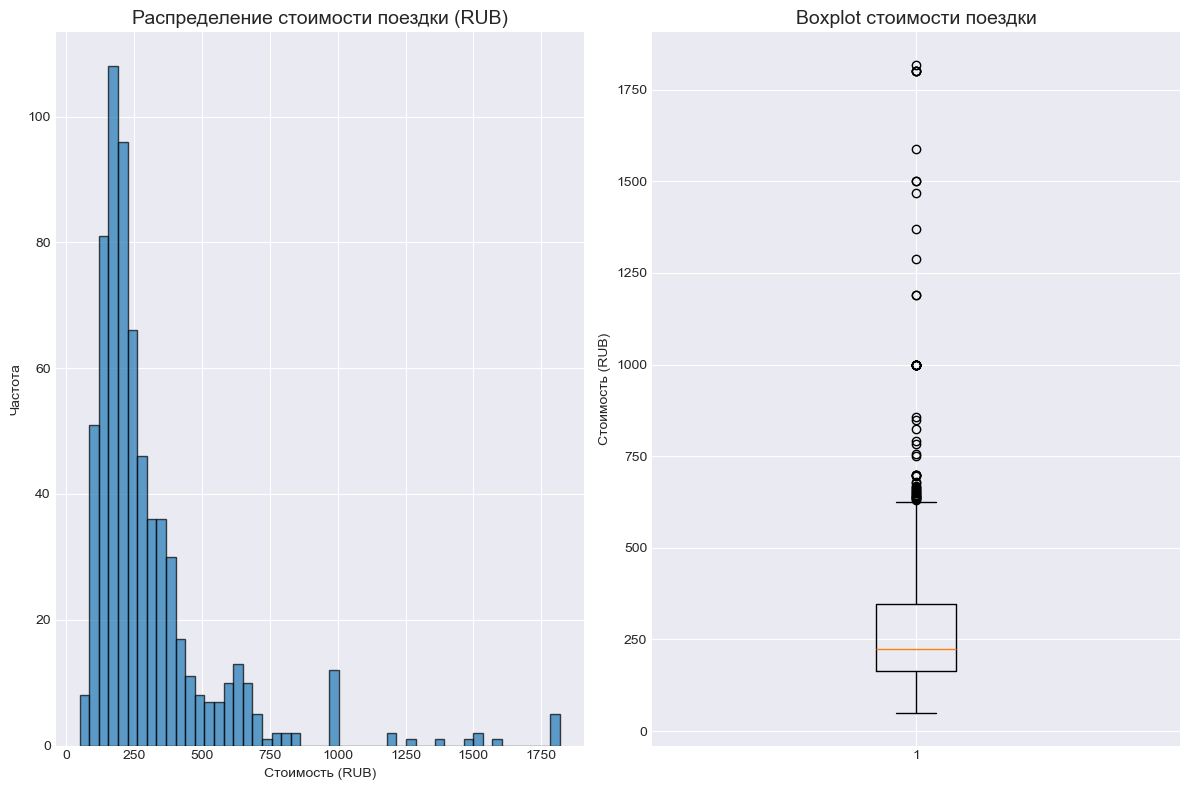

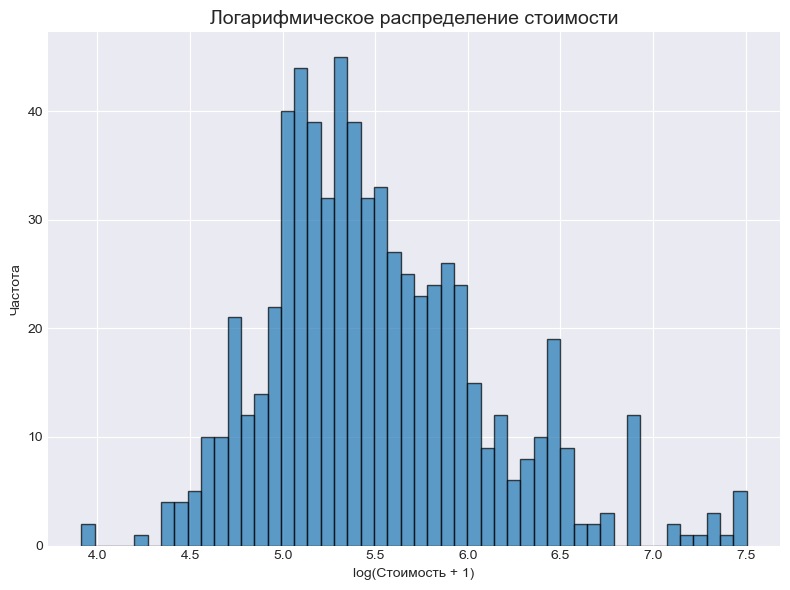

In [28]:
# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
figsize = (12, 8)

# Создаем папку для графиков
import os
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

# 5.1 Одномерный анализ (распределение целевой переменной)
print("\n📈 5.1 РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (price_rub)")
plt.figure(figsize=figsize)

if 'price_rub' in df_processed.columns:
    plt.subplot(1, 2, 1)
    plt.hist(df_processed['price_rub'], bins=50, edgecolor='black', alpha=0.7)
    plt.title('Распределение стоимости поездки (RUB)', fontsize=14)
    plt.xlabel('Стоимость (RUB)')
    plt.ylabel('Частота')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df_processed['price_rub'])
    plt.title('Boxplot стоимости поездки', fontsize=14)
    plt.ylabel('Стоимость (RUB)')
    
    plt.tight_layout()
    plt.savefig('visualizations/target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Логарифмическое преобразование для нормализации
    if df_processed['price_rub'].min() > 0:
        df_processed['price_rub_log'] = np.log1p(df_processed['price_rub'])
        plt.figure(figsize=(8, 6))
        plt.hist(df_processed['price_rub_log'], bins=50, edgecolor='black', alpha=0.7)
        plt.title('Логарифмическое распределение стоимости', fontsize=14)
        plt.xlabel('log(Стоимость + 1)')
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.savefig('visualizations/target_log_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

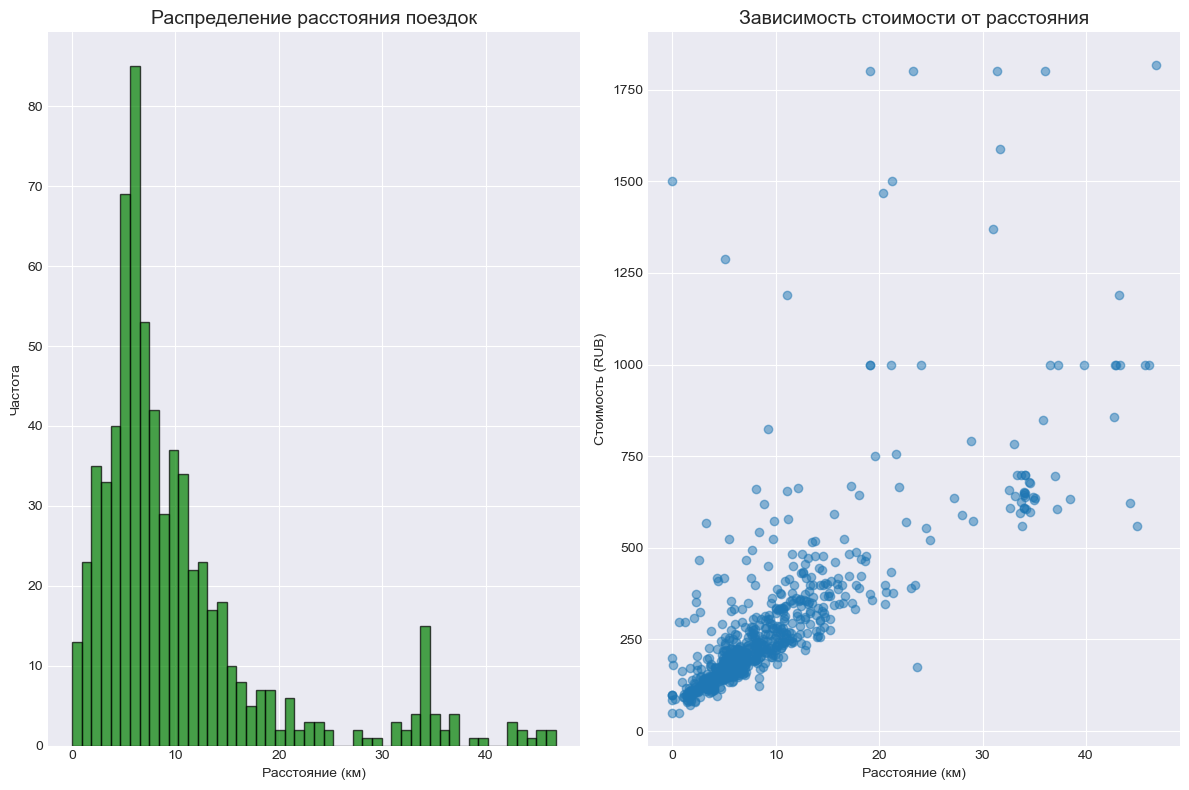

In [22]:
# 5.2 Распределение расстояния
if 'distance_kms' in df_processed.columns:
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    plt.hist(df_processed['distance_kms'], bins=50, edgecolor='black', alpha=0.7, color='green')
    plt.title('Распределение расстояния поездок', fontsize=14)
    plt.xlabel('Расстояние (км)')
    plt.ylabel('Частота')
    
    plt.subplot(1, 2, 2)
    plt.scatter(df_processed['distance_kms'], df_processed['price_rub'] if 'price_rub' in df_processed.columns else np.zeros(len(df_processed)), alpha=0.5)
    plt.title('Зависимость стоимости от расстояния', fontsize=14)
    plt.xlabel('Расстояние (км)')
    plt.ylabel('Стоимость (RUB)')
    
    plt.tight_layout()
    plt.savefig('visualizations/distance_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

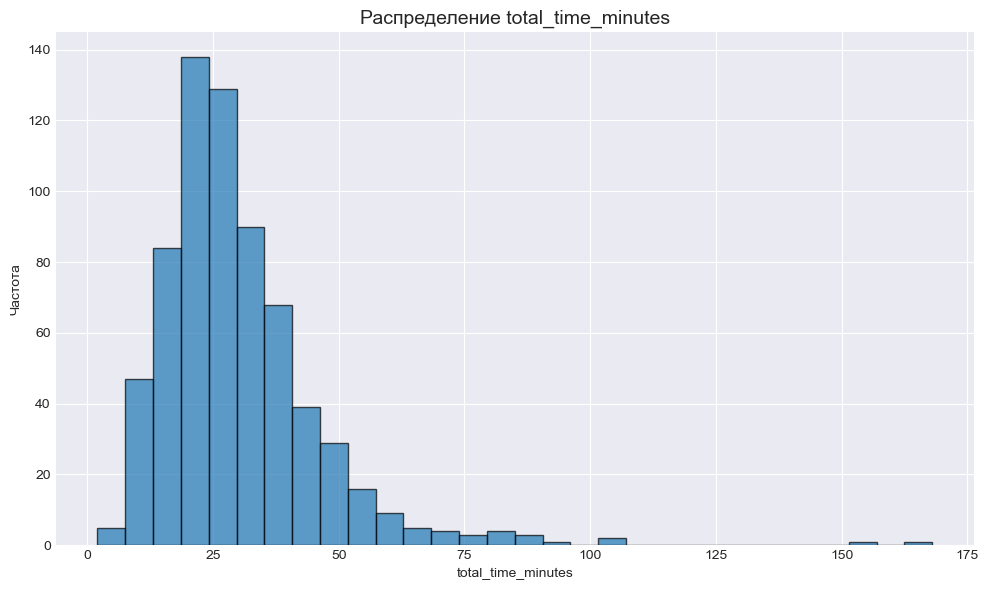

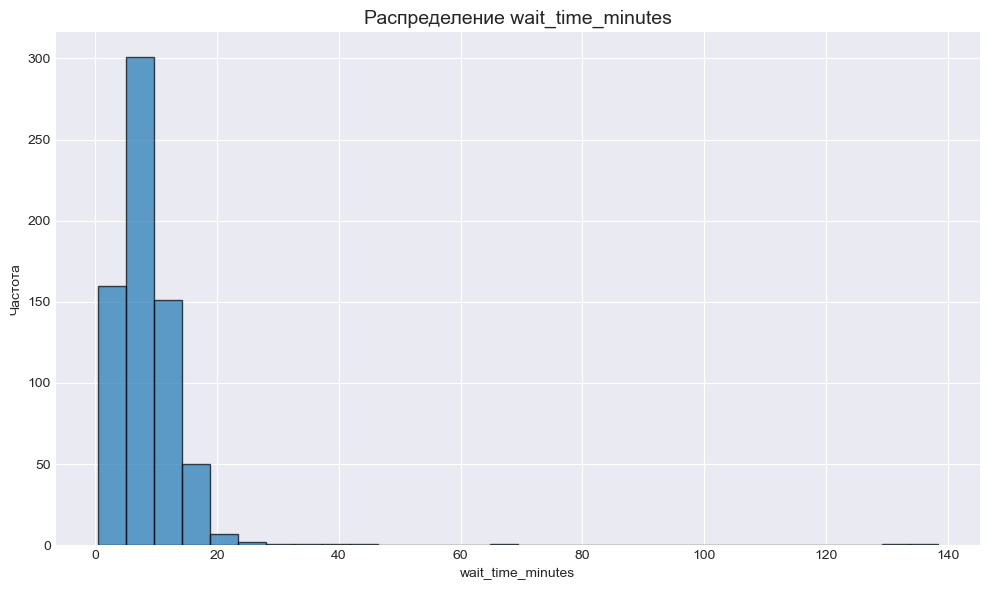

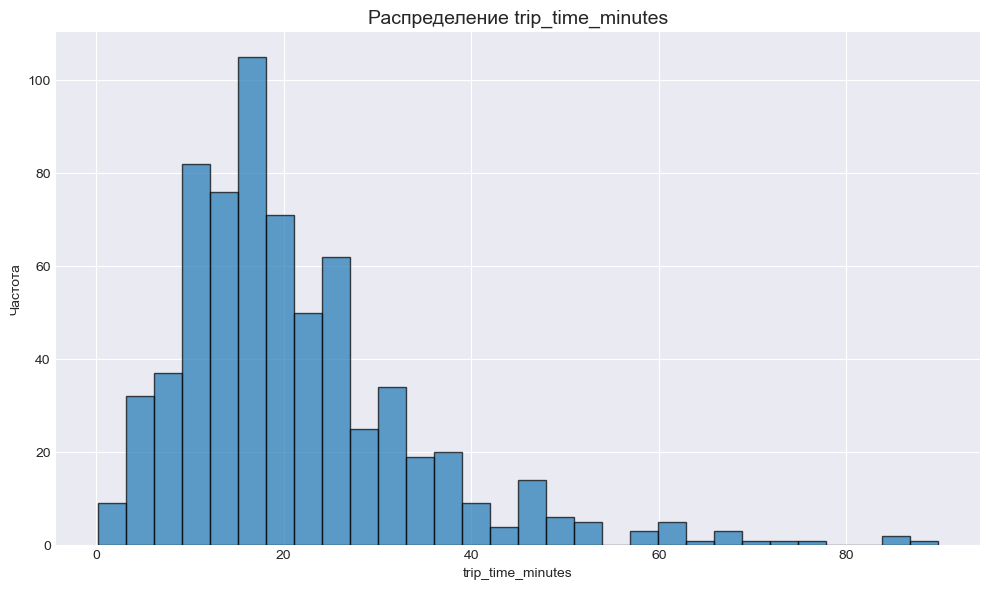

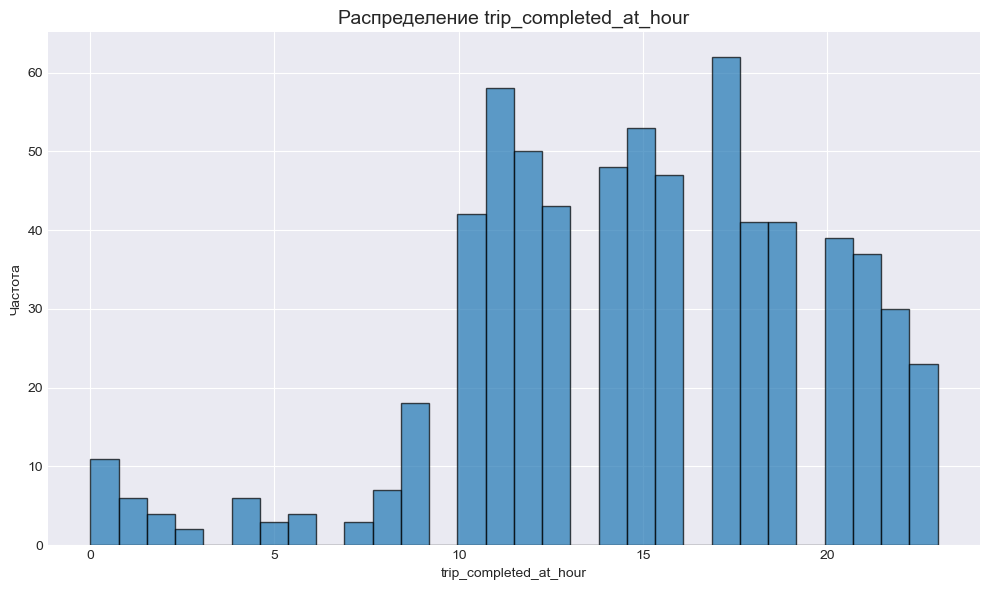

In [23]:
# 5.3 Анализ времени
time_cols = [col for col in df_processed.columns if 'minutes' in col or 'hour' in col]
for time_col in time_cols[:4]:  # Ограничиваем количество графиков
    if df_processed[time_col].nunique() > 1:
        plt.figure(figsize=(10, 6))
        plt.hist(df_processed[time_col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        plt.title(f'Распределение {time_col}', fontsize=14)
        plt.xlabel(time_col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.savefig(f'visualizations/{time_col}_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

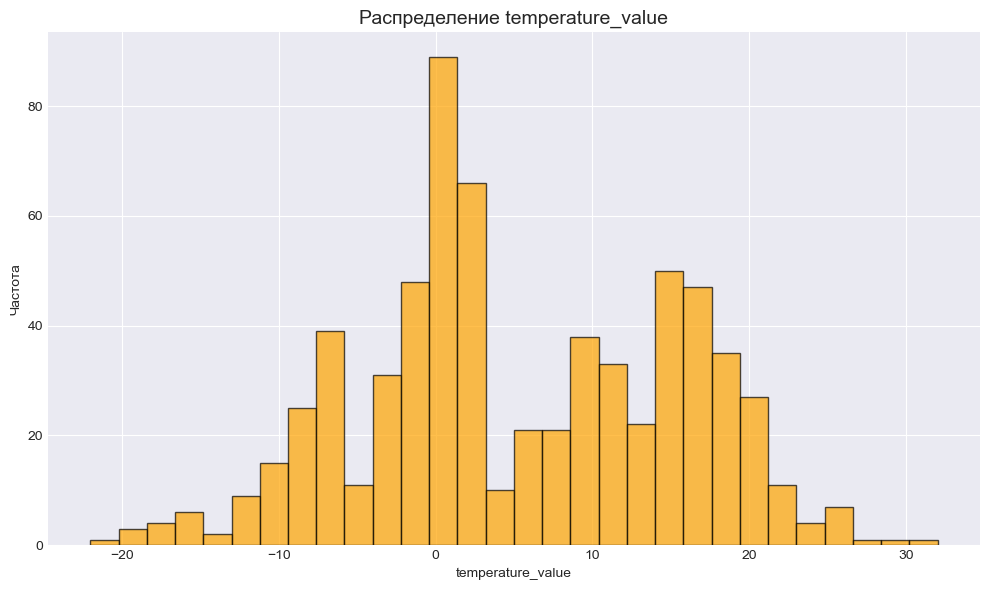

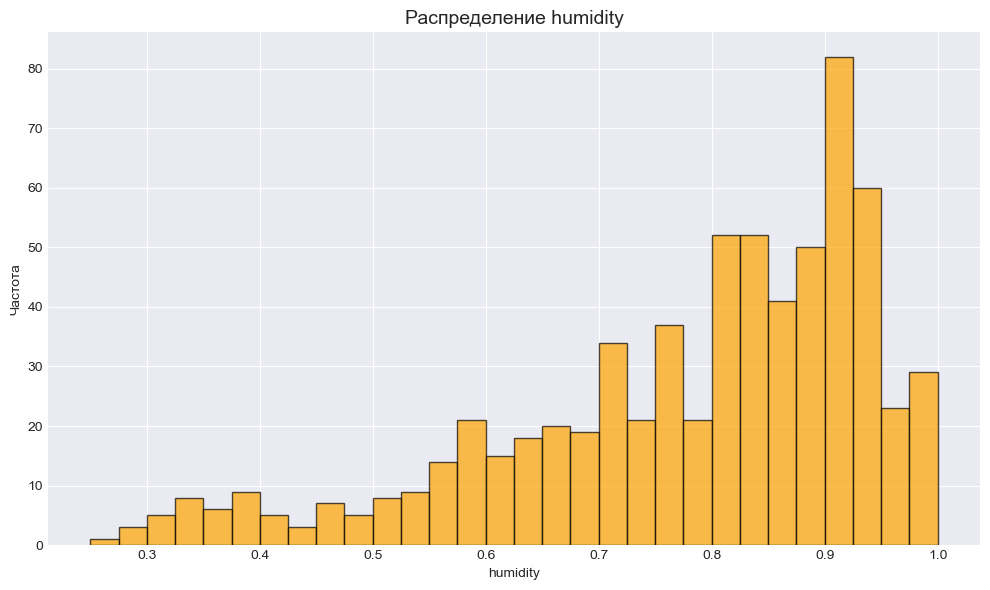

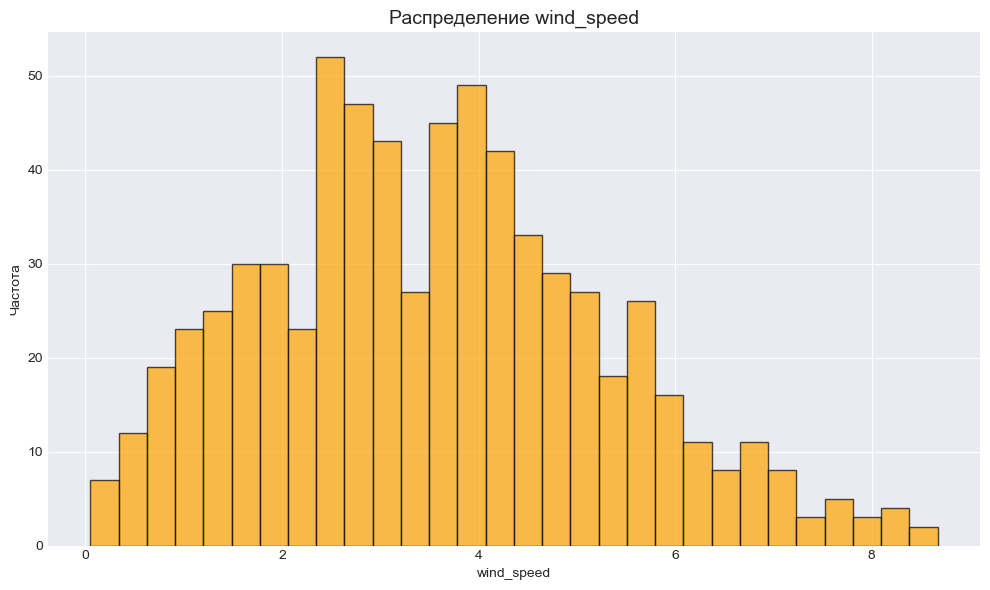

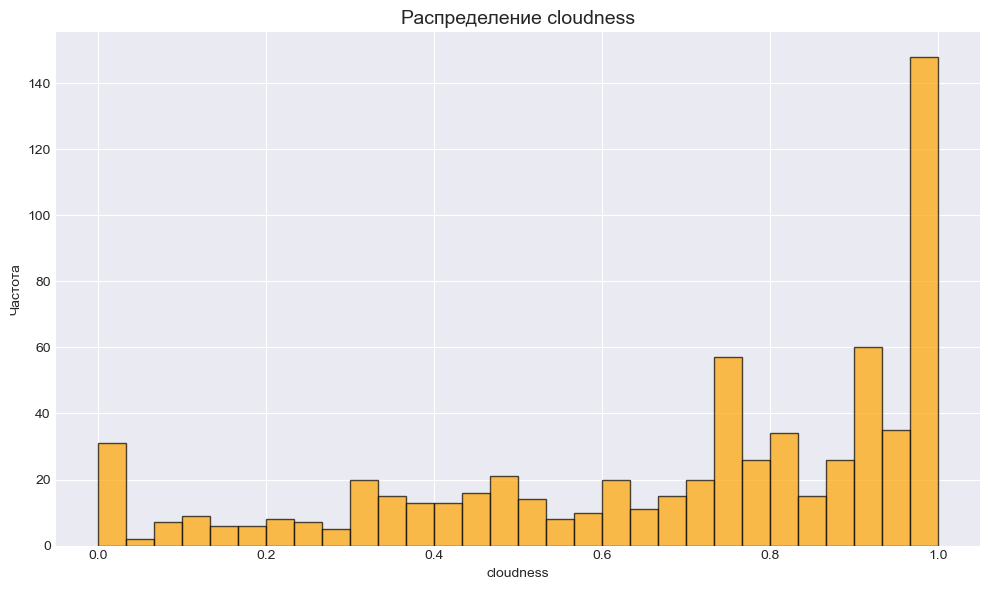

In [24]:
# 5.4 Анализ погодных условий
weather_cols = ['temperature_value', 'humidity', 'wind_speed', 'cloudness']
for col in weather_cols:
    if col in df_processed.columns:
        plt.figure(figsize=(10, 6))
        plt.hist(df_processed[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
        plt.title(f'Распределение {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.savefig(f'visualizations/{col}_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()



📊 5.5 МНОГОМЕРНЫЙ АНАЛИЗ: КОРРЕЛЯЦИОННАЯ МАТРИЦА


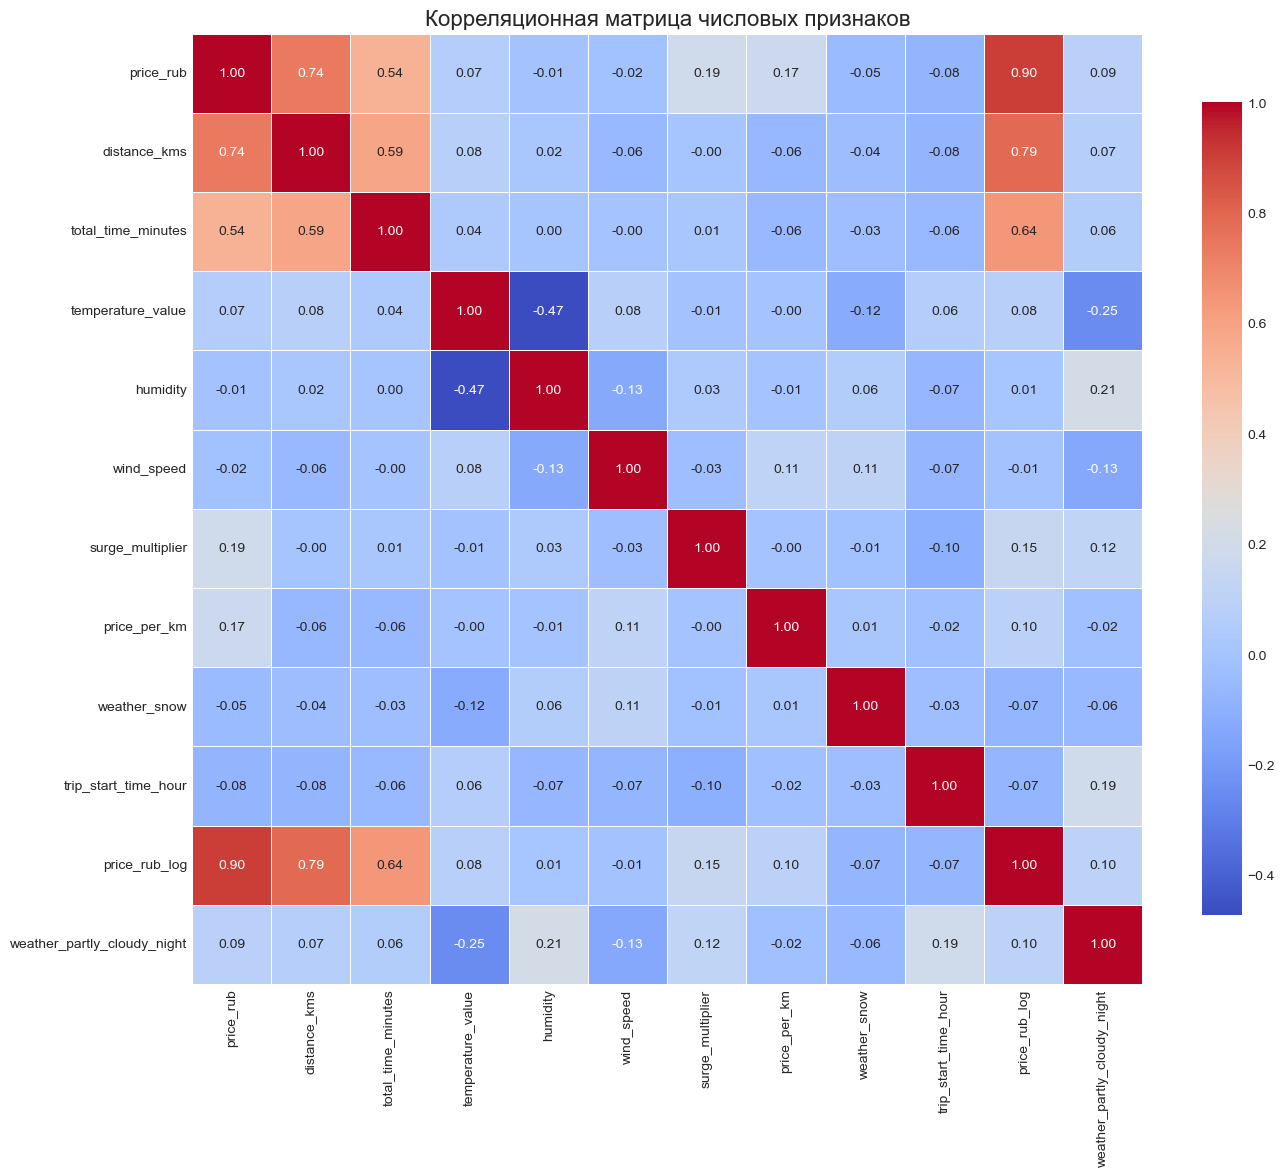


Топ корреляций со стоимостью поездки:
------------------------------------------------------------
price_rub_log                 :   0.903
distance_kms                  :   0.741
total_time_minutes            :   0.536
surge_multiplier              :   0.191
price_per_km                  :   0.171
weather_partly_cloudy_night   :   0.086
temperature_value             :   0.067
humidity                      :  -0.009
wind_speed                    :  -0.018
weather_snow                  :  -0.049
trip_start_time_hour          :  -0.081


In [25]:
# 5.5 Многомерный анализ: тепловая карта корреляций
print("\n📊 5.5 МНОГОМЕРНЫЙ АНАЛИЗ: КОРРЕЛЯЦИОННАЯ МАТРИЦА")
numeric_cols_for_corr = [col for col in df_processed.select_dtypes(include=[np.number]).columns if df_processed[col].nunique() > 1]

if len(numeric_cols_for_corr) > 1:
    # Ограничиваем количество признаков для наглядности
    if len(numeric_cols_for_corr) > 15:
        # Выбираем наиболее важные признаки
        important_cols = ['price_rub', 'distance_kms', 'total_time_minutes', 'temperature_value', 
                         'humidity', 'wind_speed', 'surge_multiplier'] if 'surge_multiplier' in df_processed.columns else []
        important_cols = [col for col in important_cols if col in numeric_cols_for_corr]
        other_cols = [col for col in numeric_cols_for_corr if col not in important_cols]
        # Добавляем еще несколько случайных признаков
        if len(other_cols) > 5:
            import random
            other_cols = random.sample(other_cols, 5)
        numeric_cols_for_corr = important_cols + other_cols
    
    corr_matrix = df_processed[numeric_cols_for_corr].corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Корреляционная матрица числовых признаков', fontsize=16)
    plt.tight_layout()
    plt.savefig('visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Выводим топ корреляций с целевой переменной
    if 'price_rub' in corr_matrix.columns:
        price_correlations = corr_matrix['price_rub'].sort_values(ascending=False)
        print("\nТоп корреляций со стоимостью поездки:")
        print("-" * 60)
        for feature, corr in price_correlations.items():
            if feature != 'price_rub':
                print(f"{feature:30s}: {corr:7.3f}")


📊 5.6 PAIRPLOT ДЛЯ ОСНОВНЫХ ПРИЗНАКОВ


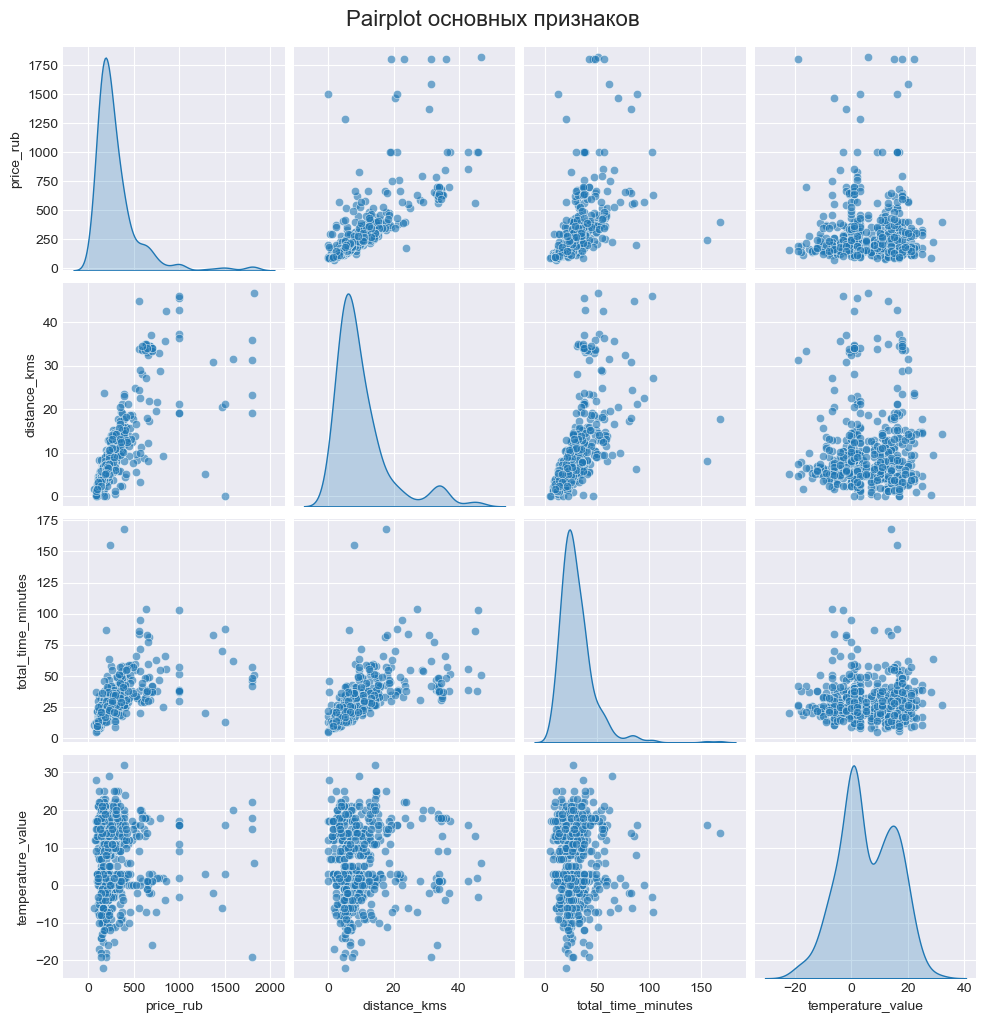

In [26]:
# 5.6 Pairplot для основных признаков
print("\n📊 5.6 PAIRPLOT ДЛЯ ОСНОВНЫХ ПРИЗНАКОВ")
main_features = ['price_rub', 'distance_kms', 'total_time_minutes', 'temperature_value']
main_features = [col for col in main_features if col in df_processed.columns]

if len(main_features) >= 3:
    try:
        sample_size = min(500, len(df_processed))
        sample_df = df_processed.sample(sample_size)[main_features]
        
        pairplot = sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.6})
        pairplot.fig.suptitle('Pairplot основных признаков', y=1.02, fontsize=16)
        plt.savefig('visualizations/pairplot_main_features.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Ошибка при создании pairplot: {e}")


📊 5.7 АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


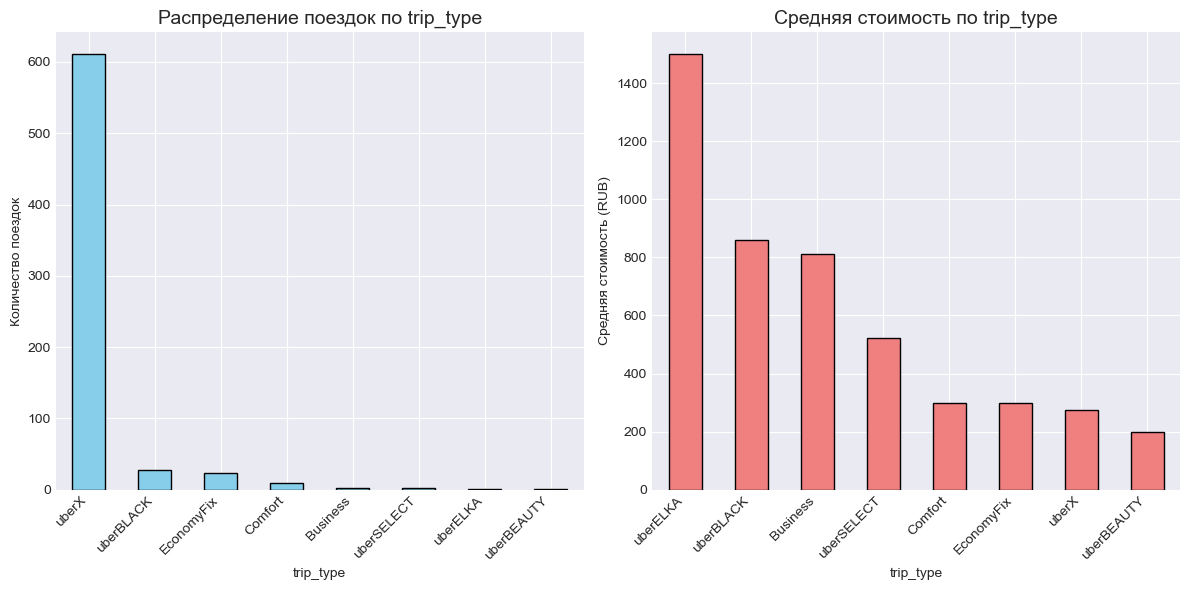

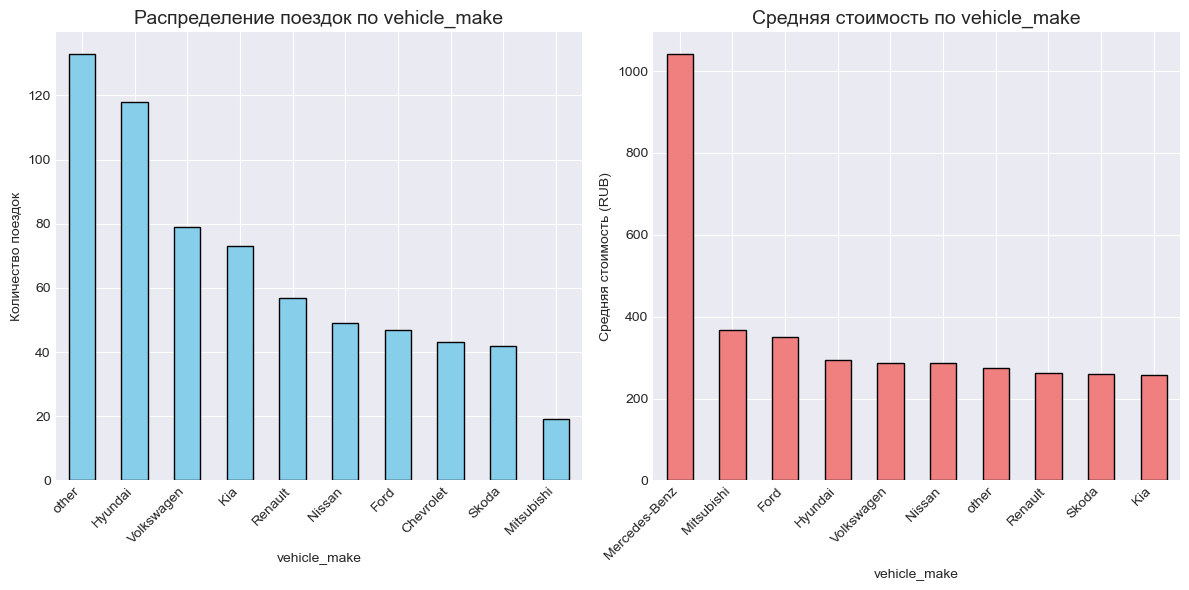

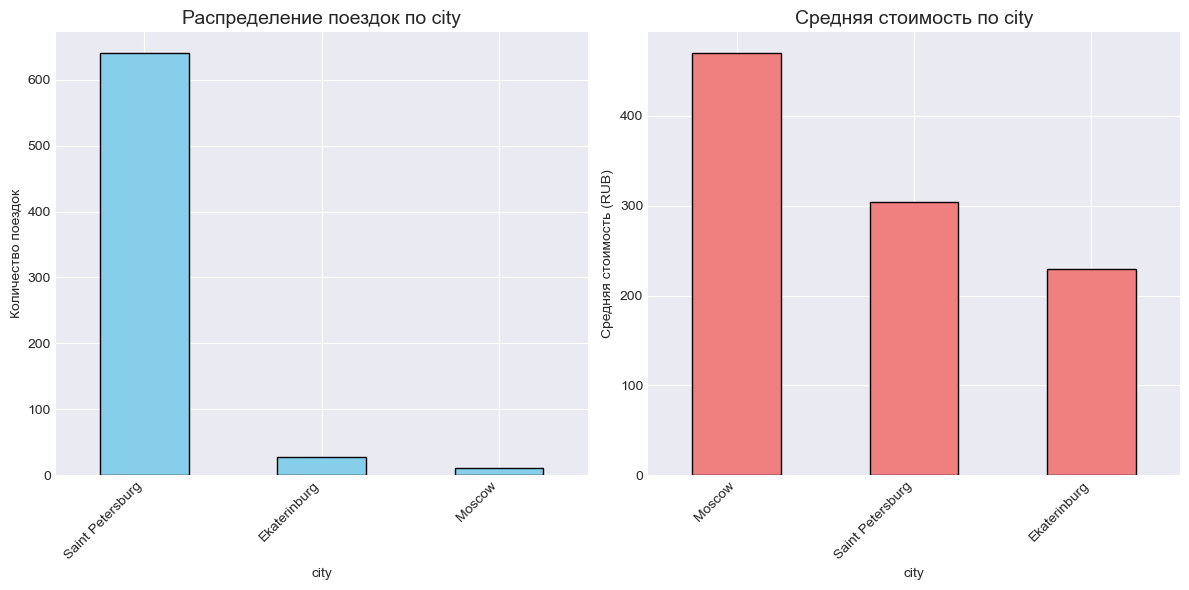

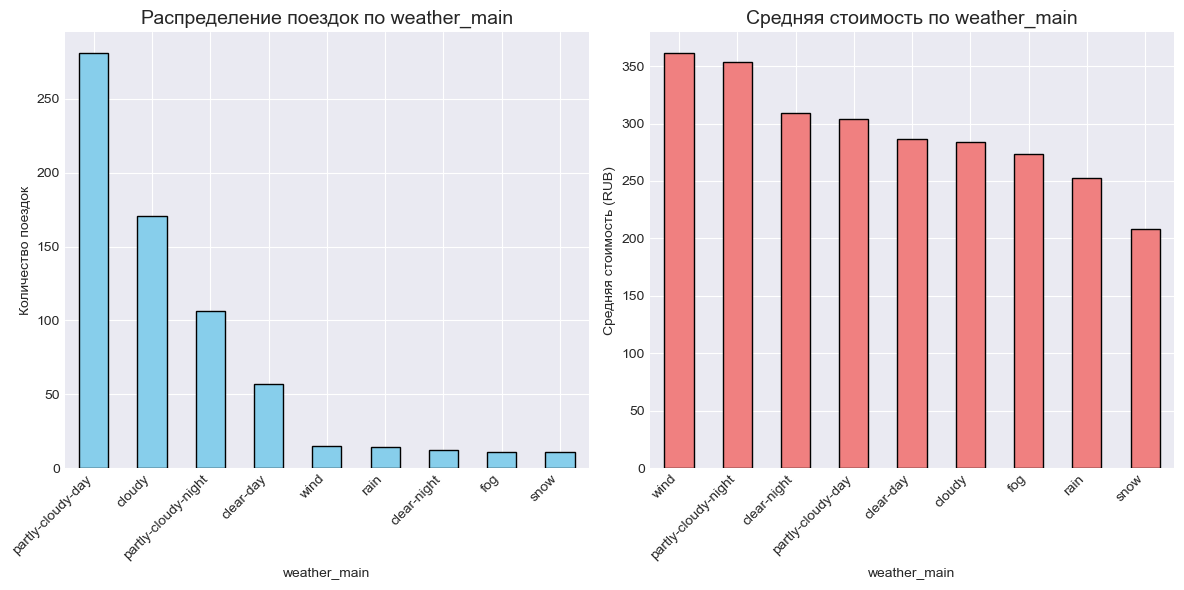

In [27]:
# 5.7 Категориальные признаки
print("\n📊 5.7 АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
categorical_cols_to_analyze = ['trip_type', 'vehicle_make', 'city', 'weather_main']
categorical_cols_to_analyze = [col for col in categorical_cols_to_analyze if col in df_processed.columns]

for cat_col in categorical_cols_to_analyze:
    if df_processed[cat_col].nunique() < 20:  # Ограничиваем количество категорий
        plt.figure(figsize=(12, 6))
        
        # График количества поездок по категориям
        plt.subplot(1, 2, 1)
        value_counts = df_processed[cat_col].value_counts().head(10)
        value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Распределение поездок по {cat_col}', fontsize=14)
        plt.xlabel(cat_col)
        plt.ylabel('Количество поездок')
        plt.xticks(rotation=45, ha='right')
        
        # График средней стоимости по категориям
        plt.subplot(1, 2, 2)
        if 'price_rub' in df_processed.columns:
            avg_price = df_processed.groupby(cat_col)['price_rub'].mean().sort_values(ascending=False).head(10)
            avg_price.plot(kind='bar', color='lightcoral', edgecolor='black')
            plt.title(f'Средняя стоимость по {cat_col}', fontsize=14)
            plt.xlabel(cat_col)
            plt.ylabel('Средняя стоимость (RUB)')
            plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(f'visualizations/{cat_col}_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

### 6. АНАЛИЗ КОРРЕЛЯЦИЙ И МУЛЬТИКОЛЛИНЕАРНОСТИ

In [29]:
# 6.1 Детальный анализ корреляций
if 'price_rub' in df_processed.columns:
    numeric_features = df_processed.select_dtypes(include=[np.number]).columns
    
    # Корреляции с целевой переменной
    correlations = {}
    for col in numeric_features:
        if col != 'price_rub' and df_processed[col].nunique() > 1:
            corr = df_processed['price_rub'].corr(df_processed[col])
            correlations[col] = corr
    
    # Сортируем по абсолютному значению корреляции
    sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
    
    print("\n📈 КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (price_rub):")
    print("-" * 70)
    print(f"{'Признак':<40} | {'Корреляция':<10} | {'Тип связи':<15}")
    print("-" * 70)
    
    for feature, corr in sorted_correlations[:20]:  # Показываем топ-20
        relation_type = "Положительная" if corr > 0 else "Отрицательная"
        strength = "Сильная" if abs(corr) > 0.5 else "Средняя" if abs(corr) > 0.3 else "Слабая"
        print(f"{feature:<40} | {corr:10.3f} | {relation_type} ({strength})")


📈 КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (price_rub):
----------------------------------------------------------------------
Признак                                  | Корреляция | Тип связи      
----------------------------------------------------------------------
price_usd                                |      0.992 | Положительная (Сильная)
price_rub_log                            |      0.903 | Положительная (Сильная)
distance_kms                             |      0.741 | Положительная (Сильная)
trip_time_minutes                        |      0.634 | Положительная (Сильная)
total_time_minutes                       |      0.536 | Положительная (Сильная)
speed_kmh                                |      0.532 | Положительная (Сильная)
trip_type_uberblack                      |      0.454 | Положительная (Средняя)
trip_type_uberx                          |     -0.356 | Отрицательная (Средняя)
surge_multiplier                         |      0.191 | Положительная (Слабая)
trip_type_uberelka 

In [30]:
# 6.2 Анализ мультиколлинеарности (VIF)
print("\n📊 6.2 АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF):")
print("-" * 60)

# Выбираем числовые признаки для VIF анализа
vif_features = [col for col in df_processed.select_dtypes(include=[np.number]).columns 
                if col != 'price_rub' and df_processed[col].nunique() > 1]

if len(vif_features) > 1:
    # Берем подмножество данных для расчета VIF
    sample_size = min(1000, len(df_processed))
    sample_data = df_processed[vif_features].dropna().sample(sample_size, random_state=42)
    
    # Добавляем константу для расчета VIF
    from statsmodels.tools.tools import add_constant
    X_vif = add_constant(sample_data)
    
    # Рассчитываем VIF для каждого признака
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    
    # Сортируем по VIF
    vif_data = vif_data.sort_values("VIF", ascending=False)
    
    print("\nVIF (фактор инфляции дисперсии):")
    print("-" * 50)
    print("VIF > 10 указывает на серьезную мультиколлинеарность")
    print("VIF > 5 указывает на умеренную мультиколлинеарность")
    print("-" * 50)
    
    for _, row in vif_data.head(15).iterrows():
        vif_level = "🚨 ВЫСОКИЙ" if row["VIF"] > 10 else "⚠ СРЕДНИЙ" if row["VIF"] > 5 else "✅ НИЗКИЙ"
        print(f"{row['feature']:30s}: VIF = {row['VIF']:6.2f} ({vif_level})")


📊 6.2 АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF):
------------------------------------------------------------

VIF (фактор инфляции дисперсии):
--------------------------------------------------
VIF > 10 указывает на серьезную мультиколлинеарность
VIF > 5 указывает на умеренную мультиколлинеарность
--------------------------------------------------
trip_start_time_hour          : VIF =    inf (🚨 ВЫСОКИЙ)
temperature_time_year         : VIF =    inf (🚨 ВЫСОКИЙ)
trip_start_time_month         : VIF =    inf (🚨 ВЫСОКИЙ)
trip_start_time_year          : VIF =    inf (🚨 ВЫСОКИЙ)
trip_end_time_month           : VIF =    inf (🚨 ВЫСОКИЙ)
trip_end_time_year            : VIF =    inf (🚨 ВЫСОКИЙ)
temperature_time_hour         : VIF =    inf (🚨 ВЫСОКИЙ)
temperature_time_dayofweek    : VIF =    inf (🚨 ВЫСОКИЙ)
temperature_time_month        : VIF =    inf (🚨 ВЫСОКИЙ)
weather_partly_cloudy_day     : VIF =    inf (🚨 ВЫСОКИЙ)
trip_completed_at_year        : VIF =    inf (🚨 ВЫСОКИЙ)
weather_partly_cloudy_night  

### # 7. ОТБОР ПРИЗНАКОВ

In [31]:
# Определяем целевую переменную
target_col = 'price_rub'
if target_col not in df_processed.columns and 'price_usd' in df_processed.columns:
    target_col = 'price_usd'
    print(f"⚠ price_rub не найден, использую {target_col} как целевую переменную")

if target_col not in df_processed.columns:
    print("❌ Целевая переменная не найдена в данных!")
    # Создаем искусственную целевую переменную для демонстрации
    df_processed[target_col] = df_processed['distance_kms'] * 30 + np.random.normal(0, 10, len(df_processed))
    print(f"Создана искусственная целевая переменная {target_col}")

# Разделяем данные на признаки и целевую переменную
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# Разделяем признаки на числовые и категориальные
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 ИСХОДНЫЕ ПРИЗНАКИ:")
print(f"  Всего признаков: {X.shape[1]}")
print(f"  Числовые признаки: {len(numeric_features)}")
print(f"  Категориальные признаки: {len(categorical_features)}")


📊 ИСХОДНЫЕ ПРИЗНАКИ:
  Всего признаков: 83
  Числовые признаки: 51
  Категориальные признаки: 28


In [32]:
# 7.1 Отбор признаков на основе корреляции
print("\n📊 7.1 ОТБОР ПРИЗНАКОВ НА ОСНОВЕ КОРРЕЛЯЦИИ")

# Рассчитываем корреляции с целевой переменной
correlation_threshold = 0.05  # Порог для слабой корреляции
strong_correlation_threshold = 0.3  # Порог для сильной корреляции

# Создаем DataFrame для хранения корреляций
corr_results = pd.DataFrame(index=numeric_features)
corr_results['correlation'] = [y.corr(X[feature]) for feature in numeric_features]
corr_results['abs_correlation'] = corr_results['correlation'].abs()

# Сортируем по абсолютной корреляции
corr_results = corr_results.sort_values('abs_correlation', ascending=False)

print(f"\nКорреляции числовых признаков с целевой переменной ({target_col}):")
print("-" * 80)
print(f"{'Признак':<40} | {'Корреляция':<12} | {'Абс.корреляция':<14} | {'Включить?'}")
print("-" * 80)

selected_numeric = []
for feature, row in corr_results.iterrows():
    abs_corr = row['abs_correlation']
    
    # Решаем, включать ли признак
    if abs_corr > correlation_threshold:
        include = "✅ ДА" if abs_corr > strong_correlation_threshold else "⚠ СЛАБАЯ"
        selected_numeric.append(feature)
    else:
        include = "❌ НЕТ"
    
    print(f"{feature:<40} | {row['correlation']:12.4f} | {abs_corr:14.4f} | {include}")

print(f"\n✅ Отобрано числовых признаков: {len(selected_numeric)} из {len(numeric_features)}")


📊 7.1 ОТБОР ПРИЗНАКОВ НА ОСНОВЕ КОРРЕЛЯЦИИ

Корреляции числовых признаков с целевой переменной (price_rub):
--------------------------------------------------------------------------------
Признак                                  | Корреляция   | Абс.корреляция | Включить?
--------------------------------------------------------------------------------
price_usd                                |       0.9923 |         0.9923 | ✅ ДА
price_rub_log                            |       0.9029 |         0.9029 | ✅ ДА
distance_kms                             |       0.7411 |         0.7411 | ✅ ДА
trip_time_minutes                        |       0.6342 |         0.6342 | ✅ ДА
total_time_minutes                       |       0.5358 |         0.5358 | ✅ ДА
speed_kmh                                |       0.5315 |         0.5315 | ✅ ДА
trip_type_uberblack                      |       0.4542 |         0.4542 | ✅ ДА
trip_type_uberx                          |      -0.3559 |         0.3559 | ✅ ДА
surg

In [33]:
# 7.2 Отбор категориальных признаков
print("\n📊 7.2 ОТБОР КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

# Анализ категориальных признаков
selected_categorical = []

print(f"\nАнализ категориальных признаков:")
print("-" * 80)
print(f"{'Признак':<30} | {'Уникальных':<12} | {'Сам.частое':<15} | {'Включить?'}")
print("-" * 80)

for feature in categorical_features:
    n_unique = X[feature].nunique()
    most_common = X[feature].value_counts().index[0] if len(X[feature].value_counts()) > 0 else 'N/A'
    most_common_count = X[feature].value_counts().iloc[0] if len(X[feature].value_counts()) > 0 else 0
    percentage = (most_common_count / len(X)) * 100
    
    # Критерии отбора
    if n_unique == 1:
        # Признак с одним значением - неинформативен
        include = "❌ НЕТ (одно значение)"
    elif n_unique > 50:
        # Слишком много уникальных значений
        include = "❌ НЕТ (>50 уникальных)"
    elif percentage > 95:
        # Одно значение доминирует
        include = f"❌ НЕТ (одно значение {percentage:.1f}%)"
    else:
        # Признак информативен
        include = "✅ ДА"
        selected_categorical.append(feature)
    
    # Ограничиваем вывод самого частого значения
    most_common_str = str(most_common)[:12] + "..." if len(str(most_common)) > 12 else str(most_common)
    
    print(f"{feature:<30} | {n_unique:<12} | {most_common_str:<15} | {include}")

print(f"\n✅ Отобрано категориальных признаков: {len(selected_categorical)} из {len(categorical_features)}")


📊 7.2 ОТБОР КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Анализ категориальных признаков:
--------------------------------------------------------------------------------
Признак                        | Уникальных   | Сам.частое      | Включить?
--------------------------------------------------------------------------------
trip_status                    | 2            | Completed       | ❌ НЕТ (одно значение 98.5%)
ride_hailing_app               | 2            | Uber            | ✅ ДА
trip_uid                       | 678          | ee89076fd9da... | ❌ НЕТ (>50 уникальных)
driver_uid                     | 628          | 164cdace271c... | ❌ НЕТ (>50 уникальных)
rider_uid                      | 1            | 3ffa4a71a5aa... | ❌ НЕТ (одно значение)
customer                       | 1            | stantyan        | ❌ НЕТ (одно значение)
trip_type                      | 8            | uberX           | ✅ ДА
vehicle_make_model             | 121          | Hyundai Sola... | ❌ НЕТ (>50 уникальных)
vehicle_lic

In [34]:
# 7.3 Объединяем отобранные признаки
print("\n📊 7.3 ОБЪЕДИНЯЕМ ОТОБРАННЫЕ ПРИЗНАКИ")

# Исключаем явно бесполезные признаки
exclude_patterns = ['_uid', '_url', '_phone', '_address', '_image', 'name_', 'license', 'completed_at', 'end_time']
exclude_columns = []

for col in selected_numeric + selected_categorical:
    for pattern in exclude_patterns:
        if pattern in col.lower():
            exclude_columns.append(col)
            break

# Удаляем исключенные признаки
selected_numeric = [col for col in selected_numeric if col not in exclude_columns]
selected_categorical = [col for col in selected_categorical if col not in exclude_columns]

# Создаем итоговый список признаков
all_selected_features = selected_numeric + selected_categorical

print(f"\nИтоговый отбор признаков:")
print("-" * 60)
print(f"Всего отобрано признаков: {len(all_selected_features)}")
print(f"  - Числовых: {len(selected_numeric)}")
print(f"  - Категориальных: {len(selected_categorical)}")
print(f"  - Исключено (паттерны): {len(exclude_columns)}")

print(f"\n📋 Список отобранных признаков:")
print("-" * 60)
for i, feature in enumerate(all_selected_features, 1):
    feature_type = "ЧИСЛОВОЙ" if feature in selected_numeric else "КАТЕГОРИАЛЬНЫЙ"
    print(f"{i:3d}. {feature:<40} [{feature_type}]")

# Создаем X с отобранными признаками
X_selected = X[all_selected_features].copy()

print(f"\n✅ Размер данных после отбора признаков: {X_selected.shape}")


📊 7.3 ОБЪЕДИНЯЕМ ОТОБРАННЫЕ ПРИЗНАКИ

Итоговый отбор признаков:
------------------------------------------------------------
Всего отобрано признаков: 35
  - Числовых: 25
  - Категориальных: 10
  - Исключено (паттерны): 8

📋 Список отобранных признаков:
------------------------------------------------------------
  1. price_usd                                [ЧИСЛОВОЙ]
  2. price_rub_log                            [ЧИСЛОВОЙ]
  3. distance_kms                             [ЧИСЛОВОЙ]
  4. trip_time_minutes                        [ЧИСЛОВОЙ]
  5. total_time_minutes                       [ЧИСЛОВОЙ]
  6. speed_kmh                                [ЧИСЛОВОЙ]
  7. trip_type_uberblack                      [ЧИСЛОВОЙ]
  8. trip_type_uberx                          [ЧИСЛОВОЙ]
  9. surge_multiplier                         [ЧИСЛОВОЙ]
 10. trip_type_uberelka                       [ЧИСЛОВОЙ]
 11. price_per_km                             [ЧИСЛОВОЙ]
 12. trip_start_time_year                     [ЧИСЛОВОЙ]


### 8. ПРЕОБРАЗОВАНИЕ ПРИЗНАКОВ


📊 8.1 ОБРАБОТКА ВЫБРОСОВ
Обрабатываю выбросы для 25 числовых признаков...

📈 СТАТИСТИКА ОБРАБОТКИ ВЫБРОСОВ:
------------------------------------------------------------
                    Признак Выбросы_до Выбросы_после     Метод
                  price_usd         70            70 winsorize
              price_rub_log         15             0 winsorize
               distance_kms         59            59 winsorize
          trip_time_minutes         30             0 winsorize
         total_time_minutes         26             0 winsorize
                  speed_kmh         43            43 winsorize
        trip_type_uberblack         27             0 winsorize
            trip_type_uberx         67            67 winsorize
           surge_multiplier         14             0 winsorize
         trip_type_uberelka          1             0 winsorize
               price_per_km         61            61 winsorize
weather_partly_cloudy_night        106           106 winsorize
       trip

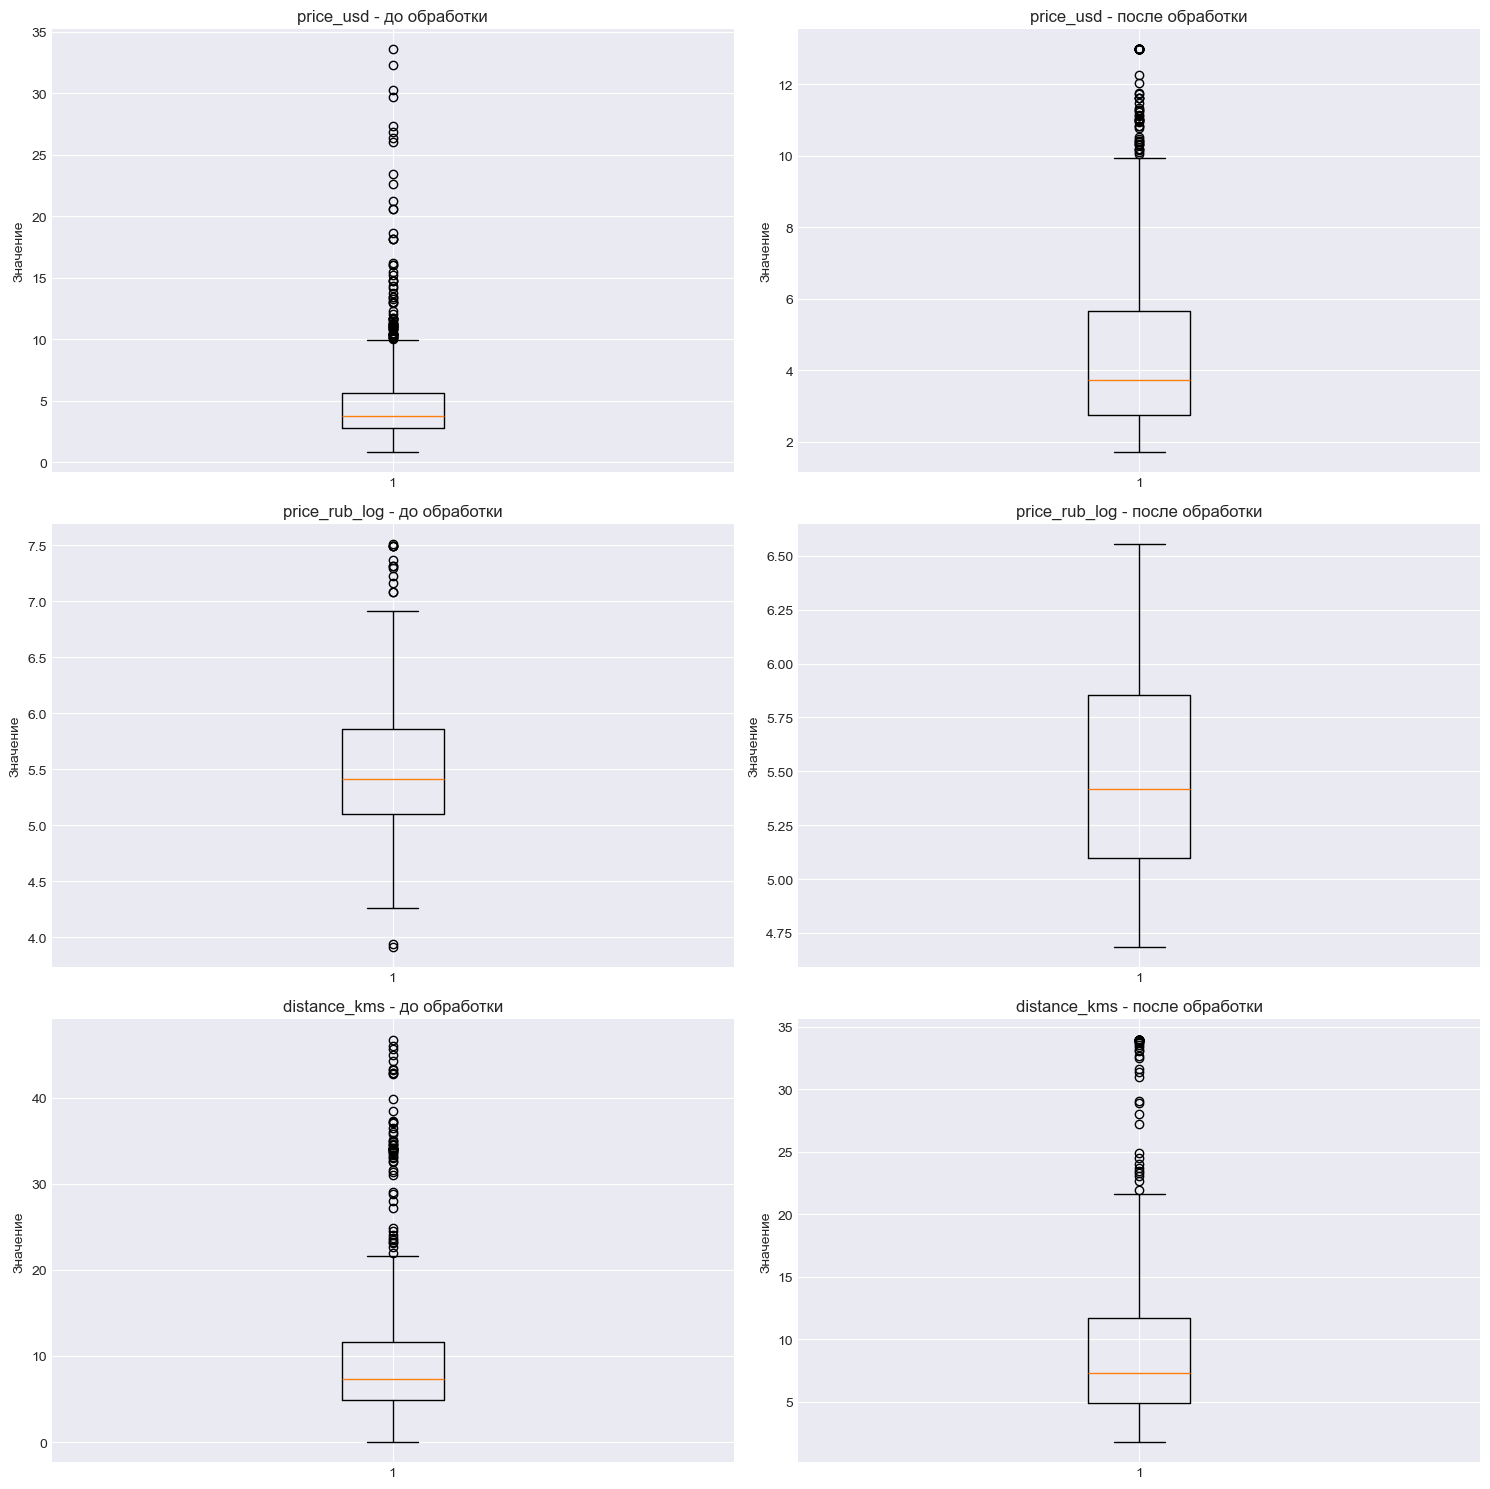

In [35]:
# 8.1 ОБРАБОТКА ВЫБРОСОВ
print("\n📊 8.1 ОБРАБОТКА ВЫБРОСОВ")

# Определяем числовые признаки для обработки выбросов
numeric_for_outliers = selected_numeric.copy()

print(f"Обрабатываю выбросы для {len(numeric_for_outliers)} числовых признаков...")

# Создаем копию данных для обработки
X_processed = X_selected.copy()

# Функция для обнаружения выбросов по методу IQR
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Обрабатываем выбросы для каждого числового признака
outliers_summary = pd.DataFrame(columns=['Признак', 'Выбросы_до', 'Выбросы_после', 'Метод'])

for feature in numeric_for_outliers:
    if feature in X_processed.columns:
        # Проверяем, есть ли достаточно данных
        if X_processed[feature].notna().sum() > 10:
            # Обнаруживаем выбросы
            outliers, lower_bound, upper_bound = detect_outliers_iqr(X_processed, feature)
            outliers_count_before = len(outliers)
            
            if outliers_count_before > 0:
                # Методы обработки выбросов
                method = 'winsorize'  # winsorize, clip, или remove
                
                if method == 'clip':
                    # Обрезаем выбросы
                    X_processed[feature] = X_processed[feature].clip(lower=lower_bound, upper=upper_bound)
                    
                elif method == 'winsorize':
                    # Винзоризация - заменяем выбросы на граничные значения
                    from scipy.stats.mstats import winsorize
                    try:
                        X_processed[feature] = winsorize(X_processed[feature], limits=[0.05, 0.05])
                    except:
                        X_processed[feature] = X_processed[feature].clip(lower=lower_bound, upper=upper_bound)
                
                elif method == 'remove':
                    # Удаляем строки с выбросами (будет сделано позже)
                    pass
                
                # Проверяем выбросы после обработки
                outliers_after, _, _ = detect_outliers_iqr(X_processed, feature)
                outliers_count_after = len(outliers_after)
                
                # Сохраняем статистику
                outliers_summary = pd.concat([outliers_summary, pd.DataFrame([{
                    'Признак': feature,
                    'Выбросы_до': outliers_count_before,
                    'Выбросы_после': outliers_count_after,
                    'Метод': method
                }])], ignore_index=True)

print(f"\n📈 СТАТИСТИКА ОБРАБОТКИ ВЫБРОСОВ:")
print("-" * 60)
if len(outliers_summary) > 0:
    print(outliers_summary.to_string(index=False))
else:
    print("Значительных выбросов не обнаружено")

# Визуализация выбросов до и после обработки
if len(numeric_for_outliers) > 0:
    # Выбираем несколько признаков для визуализации
    features_to_visualize = numeric_for_outliers[:min(3, len(numeric_for_outliers))]
    
    plt.figure(figsize=(15, 5 * len(features_to_visualize)))
    
    for i, feature in enumerate(features_to_visualize, 1):
        # До обработки
        plt.subplot(len(features_to_visualize), 2, 2*i-1)
        plt.boxplot(X_selected[feature].dropna())
        plt.title(f'{feature} - до обработки')
        plt.ylabel('Значение')
        
        # После обработки
        plt.subplot(len(features_to_visualize), 2, 2*i)
        plt.boxplot(X_processed[feature].dropna())
        plt.title(f'{feature} - после обработки')
        plt.ylabel('Значение')
    
    plt.tight_layout()
    plt.savefig('visualizations/outliers_processing.png', dpi=300, bbox_inches='tight')
    plt.show()

In [36]:
# 8.2 Преобразование категориальных признаков
print("\n📊 8.2 ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

if len(selected_categorical) > 0:
    print(f"Преобразую {len(selected_categorical)} категориальных признаков...")
    
    # Создаем копию данных для обработки
    X_categorical_processed = X_processed.copy()
    
    # Методы кодирования
    encoding_method = 'onehot'  # onehot, target, frequency
    
    # Для One-Hot Encoding ограничиваем количество категорий
    max_categories_per_feature = 10
    
    if encoding_method == 'onehot':
        print(f"Применяю One-Hot Encoding...")
        
        # Создаем список для новых признаков
        onehot_features = []
        
        for feature in selected_categorical:
            if feature in X_categorical_processed.columns:
                # Проверяем количество уникальных значений
                n_unique = X_categorical_processed[feature].nunique()
                
                if n_unique <= max_categories_per_feature:
                    # Создаем dummy-переменные
                    dummies = pd.get_dummies(
                        X_categorical_processed[feature], 
                        prefix=feature,
                        prefix_sep='_',
                        drop_first=True  # Удаляем первую категорию для избежания dummy variable trap
                    )
                    
                    # Добавляем новые признаки
                    X_categorical_processed = pd.concat([X_categorical_processed, dummies], axis=1)
                    onehot_features.extend(dummies.columns.tolist())
                    
                    # Удаляем оригинальный признак
                    X_categorical_processed = X_categorical_processed.drop(feature, axis=1)
                    
                    print(f"  {feature}: создано {len(dummies.columns)} dummy-переменных")
                else:
                    print(f"  {feature}: пропущен (> {max_categories_per_feature} уникальных значений)")
                    # Оставляем как есть или применяем другое кодирование
    
    elif encoding_method == 'target':
        print("Применяю Target Encoding...")
        # Target encoding будет сделан позже в пайплайне
    
    elif encoding_method == 'frequency':
        print("Применяю Frequency Encoding...")
        for feature in selected_categorical:
            if feature in X_categorical_processed.columns:
                # Заменяем значения на частоту их встречаемости
                freq_encoding = X_categorical_processed[feature].value_counts(normalize=True)
                X_categorical_processed[feature] = X_categorical_processed[feature].map(freq_encoding)
                print(f"  {feature}: преобразован в частоты")
    
    # Обновляем X_processed
    X_processed = X_categorical_processed.copy()
    
    print(f"\n✅ Категориальные признаки преобразованы.")
    print(f"   Новое количество признаков: {X_processed.shape[1]}")

else:
    print("✅ Категориальных признаков для преобразования нет.")

print(f"\n📊 ИТОГОВАЯ СТАТИСТИКА ПО ДАННЫМ:")
print("-" * 60)
print(f"Исходный размер: {df.shape}")
print(f"После обработки: {X_processed.shape}")
print(f"Целевая переменная: {target_col} ({y.shape})")

# Проверяем типы данных
print(f"\nТипы данных после обработки:")
print("-" * 60)
print(X_processed.dtypes.value_counts())

# Сохраняем обработанные данные
print(f"\n💾 Сохраняю обработанные данные...")
try:
    # Сохраняем обработанные признаки
    X_processed.to_csv('processed_features.csv', index=False)
    
    # Сохраняем целевую переменную
    y.to_csv('processed_target.csv', index=False)
    
    # Сохраняем список отобранных признаков
    with open('selected_features.txt', 'w') as f:
        for feature in X_processed.columns:
            f.write(f"{feature}\n")
    
    print("✅ Данные успешно сохранены:")
    print(f"   - processed_features.csv ({X_processed.shape})")
    print(f"   - processed_target.csv ({y.shape})")
    print(f"   - selected_features.txt (список признаков)")
    
except Exception as e:
    print(f"❌ Ошибка при сохранении данных: {e}")

print("\n" + "="*80)
print("🎉 ЭТАП ПРЕДВАРИТЕЛЬНОЙ ОБРАБОТКИ ДАННЫХ ЗАВЕРШЕН!")
print("="*80)


📊 8.2 ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Преобразую 10 категориальных признаков...
Применяю One-Hot Encoding...
  ride_hailing_app: создано 1 dummy-переменных
  trip_type: создано 7 dummy-переменных
  vehicle_make: пропущен (> 10 уникальных значений)
  vehicle_model: пропущен (> 10 уникальных значений)
  city: создано 2 dummy-переменных
  weather_main: создано 8 dummy-переменных
  weather_desc: пропущен (> 10 уникальных значений)
  precipitation: создано 2 dummy-переменных
  trip_start_time_timeofday: создано 3 dummy-переменных
  temperature_time_timeofday: создано 3 dummy-переменных

✅ Категориальные признаки преобразованы.
   Новое количество признаков: 54

📊 ИТОГОВАЯ СТАТИСТИКА ПО ДАННЫМ:
------------------------------------------------------------
Исходный размер: (678, 45)
После обработки: (678, 54)
Целевая переменная: price_rub ((678,))

Типы данных после обработки:
------------------------------------------------------------
bool       26
float64    15
int32      10
object

In [37]:
print("\n📊 8.4 ИСПРАВЛЕНИЕ DATA LEAKAGE")
print("="*60)

# Удаляем признаки, которые содержат информацию о целевой переменной (data leakage)
leakage_features = ['price_usd', 'price_rub_log', 'price_per_km']
features_to_remove = []

for feature in leakage_features:
    if feature in X_processed.columns:
        features_to_remove.append(feature)
        print(f"❌ Удаляю {feature} (содержит целевую переменную)")

# Также удаляем признаки с высокой корреляцией между собой
high_correlation_features = ['trip_end_time_year', 'temperature_time_year']
for feature in high_correlation_features:
    if feature in X_processed.columns:
        features_to_remove.append(feature)
        print(f"❌ Удаляю {feature} (высокая корреляция с trip_start_time_year)")

# Удаляем эти признаки
X_processed_clean = X_processed.drop(columns=features_to_remove, errors='ignore')

print(f"\n✅ После очистки: {X_processed_clean.shape[1]} признаков")
print(f"   Удалено признаков: {len(features_to_remove)}")


📊 8.4 ИСПРАВЛЕНИЕ DATA LEAKAGE
❌ Удаляю price_usd (содержит целевую переменную)
❌ Удаляю price_rub_log (содержит целевую переменную)
❌ Удаляю price_per_km (содержит целевую переменную)
❌ Удаляю temperature_time_year (высокая корреляция с trip_start_time_year)

✅ После очистки: 50 признаков
   Удалено признаков: 4



📊 8.3 МАСШТАБИРОВАНИЕ ПРИЗНАКОВ (StandardScaler):
  Финальный набор данных: (678, 50)
  Типы данных в X_final:
bool       26
float64    12
int32       9
object      3
Name: count, dtype: int64

⚠ Обнаружены категориальные признаки: 29
  Преобразую их в числовой формат...
    vehicle_make: frequency encoded
    vehicle_model: frequency encoded
    weather_desc: frequency encoded
    ride_hailing_app_Uber: bool → int
    trip_type_Comfort: bool → int
    trip_type_EconomyFix: bool → int
    trip_type_uberBEAUTY: bool → int
    trip_type_uberBLACK: bool → int
    trip_type_uberELKA: bool → int
    trip_type_uberSELECT: bool → int
    trip_type_uberX: bool → int
    city_Moscow: bool → int
    city_Saint Petersburg: bool → int
    weather_main_clear-night: bool → int
    weather_main_cloudy: bool → int
    weather_main_fog: bool → int
    weather_main_partly-cloudy-day: bool → int
    weather_main_partly-cloudy-night: bool → int
    weather_main_rain: bool → int
    weather_main_snow: boo

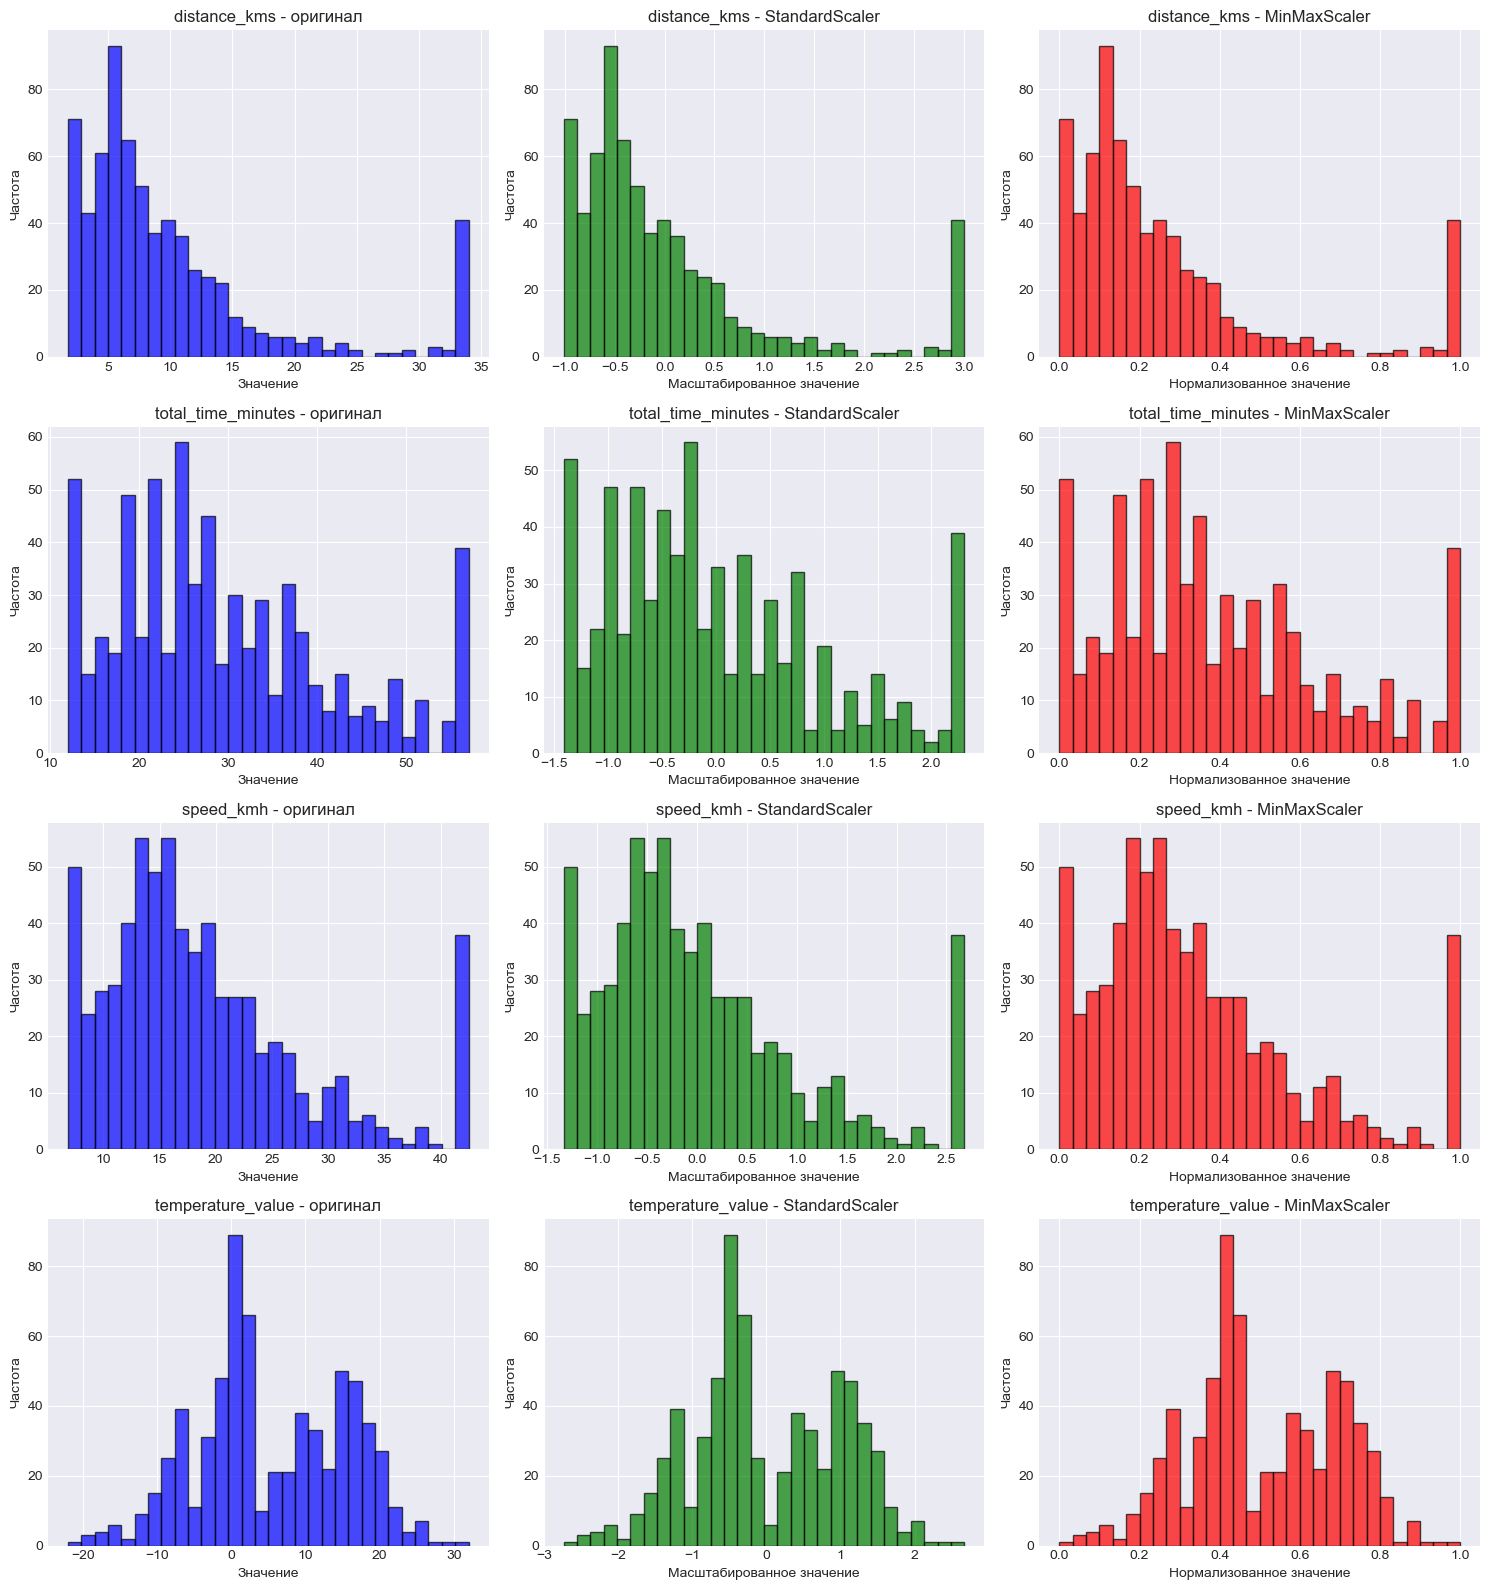


📊 Статистика по основным признакам после преобразования:
------------------------------------------------------------
distance_kms:
  Мин: 1.79, Макс: 33.97
  Среднее: 9.90, Медиана: 7.29

total_time_minutes:
  Мин: 12.00, Макс: 57.00
  Среднее: 29.11, Медиана: 26.00

💾 Сохраняю финальные данные...
✅ Финальные данные сохранены:
   - final_features.csv ((678, 50))
   - final_target.csv ((678,))
   - final_features_list.txt (50 признаков)


In [39]:
# ============================
# 8.3 Масштабирование признаков (исправленная версия)
# ============================
print("\n📊 8.3 МАСШТАБИРОВАНИЕ ПРИЗНАКОВ (StandardScaler):")

# Создаем финальный набор признаков для моделирования
X_final = X_processed_clean.copy()

print(f"  Финальный набор данных: {X_final.shape}")
print(f"  Типы данных в X_final:")
print(X_final.dtypes.value_counts())

# Проверяем наличие категориальных признаков
categorical_cols = X_final.select_dtypes(include=['object', 'bool']).columns.tolist()
if categorical_cols:
    print(f"\n⚠ Обнаружены категориальные признаки: {len(categorical_cols)}")
    print("  Преобразую их в числовой формат...")
    
    # Создаем копию для преобразования
    X_final_numeric = X_final.copy()
    
    # Преобразуем bool в int (0/1)
    for col in categorical_cols:
        if X_final_numeric[col].dtype == 'bool':
            X_final_numeric[col] = X_final_numeric[col].astype(int)
            print(f"    {col}: bool → int")
        elif X_final_numeric[col].nunique() <= 10:
            # Для признаков с небольшим количеством уникальных значений применяем one-hot encoding
            dummies = pd.get_dummies(X_final_numeric[col], prefix=col, drop_first=True)
            X_final_numeric = pd.concat([X_final_numeric, dummies], axis=1)
            X_final_numeric = X_final_numeric.drop(col, axis=1)
            print(f"    {col}: one-hot encoded ({len(dummies.columns)} dummy variables)")
        else:
            # Для признаков с большим количеством уникальных значений применяем frequency encoding
            freq = X_final_numeric[col].value_counts(normalize=True)
            X_final_numeric[col] = X_final_numeric[col].map(freq)
            print(f"    {col}: frequency encoded")
    
    # Обновляем X_final
    X_final = X_final_numeric

print(f"\n  Типы данных после преобразования:")
print(X_final.dtypes.value_counts())

# Проверяем наличие нечисловых значений
non_numeric_cols = X_final.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print(f"\n⚠ Остались нечисловые колонки: {non_numeric_cols}")
    print("  Применяю Label Encoding к оставшимся признакам...")
    
    for col in non_numeric_cols:
        if X_final[col].nunique() > 1:
            le = LabelEncoder()
            X_final[col] = le.fit_transform(X_final[col].astype(str))
            print(f"    {col}: label encoded ({X_final[col].nunique()} unique values)")
        else:
            # Если только одно значение, удаляем признак
            print(f"    {col}: удален (только одно уникальное значение)")
            X_final = X_final.drop(col, axis=1)

# Убедимся, что все значения числовые
for col in X_final.columns:
    try:
        X_final[col] = pd.to_numeric(X_final[col], errors='coerce')
    except:
        print(f"    {col}: не удалось преобразовать в числовой формат")

# Заполняем пропущенные значения, если есть
if X_final.isnull().sum().sum() > 0:
    print(f"\n⚠ Обнаружены пропущенные значения: {X_final.isnull().sum().sum()}")
    print("  Заполняю медианами...")
    for col in X_final.columns:
        missing_count = X_final[col].isnull().sum()
        if missing_count > 0:
            median_val = X_final[col].median()
            X_final[col] = X_final[col].fillna(median_val)
            print(f"    {col}: {missing_count} пропусков заполнено медианой {median_val:.2f}")

print(f"\n  Финальный размер данных: {X_final.shape}")
print(f"  Целевая переменная: {y.name} ({y.shape})")

# Теперь масштабируем данные
# Стандартизация (StandardScaler) - вариант по умолчанию
scaler_standard = StandardScaler()
X_scaled_standard = scaler_standard.fit_transform(X_final)
X_scaled_standard = pd.DataFrame(X_scaled_standard, columns=X_final.columns)

# Нормализация (MinMaxScaler) - для сравнения
scaler_minmax = MinMaxScaler()
X_scaled_minmax = scaler_minmax.fit_transform(X_final)
X_scaled_minmax = pd.DataFrame(X_scaled_minmax, columns=X_final.columns)

print(f"  Стандартизация применена к {X_final.shape[1]} признакам")

# Сохраняем имена признаков после преобразования
feature_names = X_final.columns.tolist()

# Визуализация распределения признаков до и после масштабирования
print("\n📊 Визуализация масштабирования признаков...")

# Выбираем несколько признаков для визуализации
features_to_visualize = ['distance_kms', 'total_time_minutes', 'speed_kmh', 'temperature_value']
features_to_visualize = [f for f in features_to_visualize if f in feature_names]

if features_to_visualize:
    fig, axes = plt.subplots(len(features_to_visualize), 3, figsize=(15, 4*len(features_to_visualize)))
    
    for i, feature in enumerate(features_to_visualize):
        # Оригинальные данные
        axes[i, 0].hist(X_final[feature].dropna(), bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i, 0].set_title(f'{feature} - оригинал')
        axes[i, 0].set_xlabel('Значение')
        axes[i, 0].set_ylabel('Частота')
        
        # StandardScaler
        axes[i, 1].hist(X_scaled_standard[feature].dropna(), bins=30, alpha=0.7, color='green', edgecolor='black')
        axes[i, 1].set_title(f'{feature} - StandardScaler')
        axes[i, 1].set_xlabel('Масштабированное значение')
        axes[i, 1].set_ylabel('Частота')
        
        # MinMaxScaler
        axes[i, 2].hist(X_scaled_minmax[feature].dropna(), bins=30, alpha=0.7, color='red', edgecolor='black')
        axes[i, 2].set_title(f'{feature} - MinMaxScaler')
        axes[i, 2].set_xlabel('Нормализованное значение')
        axes[i, 2].set_ylabel('Частота')
    
    plt.tight_layout()
    plt.savefig('visualizations/scaling_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Также визуализируем несколько других важных признаков
print("\n📊 Статистика по основным признакам после преобразования:")
print("-" * 60)

# Базовые статистики
if 'distance_kms' in X_final.columns:
    print(f"distance_kms:")
    print(f"  Мин: {X_final['distance_kms'].min():.2f}, Макс: {X_final['distance_kms'].max():.2f}")
    print(f"  Среднее: {X_final['distance_kms'].mean():.2f}, Медиана: {X_final['distance_kms'].median():.2f}")

if 'total_time_minutes' in X_final.columns:
    print(f"\ntotal_time_minutes:")
    print(f"  Мин: {X_final['total_time_minutes'].min():.2f}, Макс: {X_final['total_time_minutes'].max():.2f}")
    print(f"  Среднее: {X_final['total_time_minutes'].mean():.2f}, Медиана: {X_final['total_time_minutes'].median():.2f}")

# Сохраняем финальные данные
print(f"\n💾 Сохраняю финальные данные...")
X_final.to_csv('final_features.csv', index=False)
y.to_csv('final_target.csv', index=False)

# Сохраняем список финальных признаков
with open('final_features_list.txt', 'w', encoding='utf-8') as f:
    for i, feature in enumerate(feature_names, 1):
        f.write(f"{i:3d}. {feature}\n")

print("✅ Финальные данные сохранены:")
print(f"   - final_features.csv ({X_final.shape})")
print(f"   - final_target.csv ({y.shape})")
print(f"   - final_features_list.txt ({len(feature_names)} признаков)")

### 9. РАЗДЕЛЕНИЕ ДАННЫХ (исправленная версия)

ШАГ: РАЗДЕЛЕНИЕ ДАННЫХ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
Разделение данных (80% train, 20% test)...
✅ Разделение завершено:
   Обучающая выборка: 542 samples
   Тестовая выборка: 136 samples
   Количество признаков: 50


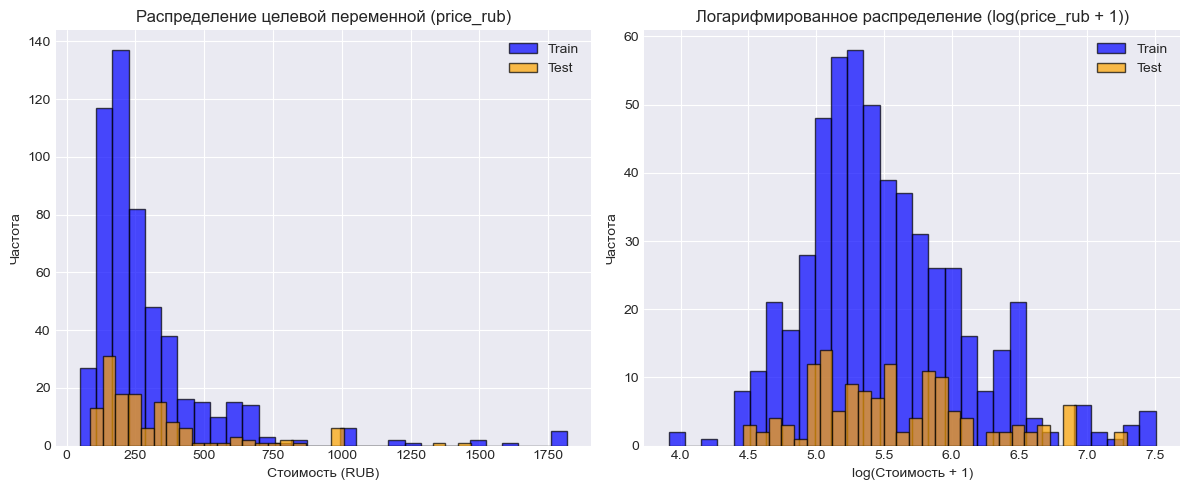

In [40]:
print("ШАГ: РАЗДЕЛЕНИЕ ДАННЫХ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ")
print("="*60)

# Создаем копии для разных подходов к масштабированию
X_final_original = X_final.copy()  # Сохраняем оригинальные данные
y_original = y.copy()

print("Разделение данных (80% train, 20% test)...")

# Подход 1: Стандартизованные данные
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(
    X_scaled_standard, y, test_size=0.2, random_state=42, shuffle=True
)

# Подход 2: Нормализованные данные
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(
    X_scaled_minmax, y, test_size=0.2, random_state=42, shuffle=True
)

# Подход 3: Оригинальные данные (без масштабирования)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_final_original, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"✅ Разделение завершено:")
print(f"   Обучающая выборка: {X_train_std.shape[0]} samples")
print(f"   Тестовая выборка: {X_test_std.shape[0]} samples")
print(f"   Количество признаков: {X_train_std.shape[1]}")

# Визуализация распределения целевой переменной в train и test
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train_std, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
plt.hist(y_test_std, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
plt.title('Распределение целевой переменной (price_rub)')
plt.xlabel('Стоимость (RUB)')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
# Логарифмированное распределение
y_train_log = np.log1p(y_train_std)
y_test_log = np.log1p(y_test_std)
plt.hist(y_train_log, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
plt.hist(y_test_log, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
plt.title('Логарифмированное распределение (log(price_rub + 1))')
plt.xlabel('log(Стоимость + 1)')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.savefig('visualizations/train_test_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 10. ОБУЧЕНИЕ МОДЕЛЕЙ (исправленная версия)

In [42]:
print("\n" + "="*60)
print("ШАГ: ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ")
print("="*60)

# Определяем модели для тестирования
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=5, random_state=42, verbose=-1)
}

# Функция для оценки модели (улучшенная)
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, scaling_type):
    """Оценивает модель и возвращает метрики"""
    
    try:
        # Время начала обучения
        start_time = time.time()
        
        # Обучение модели
        model.fit(X_train, y_train)
        
        # Время обучения
        train_time = time.time() - start_time
        
        # Предсказания
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Расчет метрик
        metrics = {
            'scaling_type': scaling_type,
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'train_r2': r2_score(y_train, y_train_pred),
            'test_r2': r2_score(y_test, y_test_pred),
            'train_time': train_time
        }
        
        # Расчет MAPE (Mean Absolute Percentage Error)
        try:
            # Избегаем деления на ноль
            mask_train = y_train != 0
            mask_test = y_test != 0
            
            if np.sum(mask_train) > 0:
                mape_train = np.mean(np.abs((y_train[mask_train] - y_train_pred[mask_train]) / y_train[mask_train])) * 100
            else:
                mape_train = None
                
            if np.sum(mask_test) > 0:
                mape_test = np.mean(np.abs((y_test[mask_test] - y_test_pred[mask_test]) / y_test[mask_test])) * 100
            else:
                mape_test = None
                
            metrics.update({
                'train_mape': mape_train,
                'test_mape': mape_test
            })
        except:
            metrics.update({
                'train_mape': None,
                'test_mape': None
            })
        
        return model, metrics, y_test_pred
        
    except Exception as e:
        print(f"  Ошибка при обучении {model_name}: {str(e)}")
        return None, None, None

# Импортируем time для измерения
import time

# Обучаем и оцениваем модели для каждого типа масштабирования
results = {}
all_predictions = {}

print("\n📊 ОЦЕНКА МОДЕЛЕЙ С РАЗНЫМИ ВИДАМИ МАСШТАБИРОВАНИЯ:")
print("-" * 80)

# Списки данных для разных типов масштабирования
data_configs = [
    ('StandardScaler', X_train_std, X_test_std, y_train_std, y_test_std),
    ('MinMaxScaler', X_train_mm, X_test_mm, y_train_mm, y_test_mm),
    ('No Scaling', X_train_orig, X_test_orig, y_train_orig, y_test_orig)
]

for scaling_type, X_train, X_test, y_train, y_test in data_configs:
    print(f"\n🔧 Масштабирование: {scaling_type}")
    print("-" * 50)
    
    scaling_results = {}
    
    for model_name, model in models.items():
        print(f"  Обучение {model_name:20s}...", end=" ")
        
        trained_model, metrics, y_pred = evaluate_model(
            model, X_train, X_test, y_train, y_test, model_name, scaling_type
        )
        
        if metrics:
            scaling_results[model_name] = metrics
            all_predictions[(scaling_type, model_name)] = (y_pred, trained_model)
            
            # Вывод основных метрик
            print(f"✅ Test R² = {metrics['test_r2']:.4f}, Test RMSE = {metrics['test_rmse']:.2f}, Time = {metrics['train_time']:.2f}s")
        else:
            print(f"❌ Ошибка")
    
    results[scaling_type] = scaling_results


ШАГ: ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ

📊 ОЦЕНКА МОДЕЛЕЙ С РАЗНЫМИ ВИДАМИ МАСШТАБИРОВАНИЯ:
--------------------------------------------------------------------------------

🔧 Масштабирование: StandardScaler
--------------------------------------------------
  Обучение Linear Regression   ... ✅ Test R² = 0.8058, Test RMSE = 111.30, Time = 0.04s
  Обучение Ridge Regression    ... ✅ Test R² = 0.8071, Test RMSE = 110.94, Time = 0.01s
  Обучение Lasso Regression    ... ✅ Test R² = 0.8061, Test RMSE = 111.20, Time = 0.19s
  Обучение Decision Tree       ... ✅ Test R² = 0.7067, Test RMSE = 136.80, Time = 0.02s
  Обучение Random Forest       ... ✅ Test R² = 0.7852, Test RMSE = 117.06, Time = 0.47s
  Обучение Gradient Boosting   ... ✅ Test R² = 0.7896, Test RMSE = 115.85, Time = 0.48s
  Обучение XGBoost             ... ✅ Test R² = 0.8117, Test RMSE = 109.60, Time = 0.20s
  Обучение LightGBM            ... ✅ Test R² = 0.7545, Test RMSE = 125.14, Time = 0.38s

🔧 Масштабирование: MinMaxScaler
------------

### 11. СРАВНЕНИЕ РЕЗУЛЬТАТОВ


ШАГ: СРАВНЕНИЕ РЕЗУЛЬТАТОВ МОДЕЛЕЙ

📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (топ-10 моделей):
----------------------------------------------------------------------------------------------------
Масштабирование            Модель  Test R²  Test RMSE  Test MAE  Train R²  Train RMSE  Train MAE  Train Time  Train MAPE  Test MAPE
     No Scaling           XGBoost 0.811693 109.602661 60.896490  0.999941    1.909369   1.386413    0.136105    0.654196  18.182691
 StandardScaler           XGBoost 0.811693 109.602661 60.896490  0.999941    1.909369   1.386413    0.195225    0.654196  18.182691
   MinMaxScaler           XGBoost 0.811693 109.602661 60.896490  0.999941    1.909369   1.386413    0.137001    0.654196  18.182691
 StandardScaler  Ridge Regression 0.807070 110.940016 72.070195  0.829811  102.622694  59.214513    0.010998   19.843001  23.761632
   MinMaxScaler  Lasso Regression 0.806730 111.037665 72.047864  0.829930  102.586791  59.220085    0.043659   19.820986  23.794790
     No Scaling  Lasso

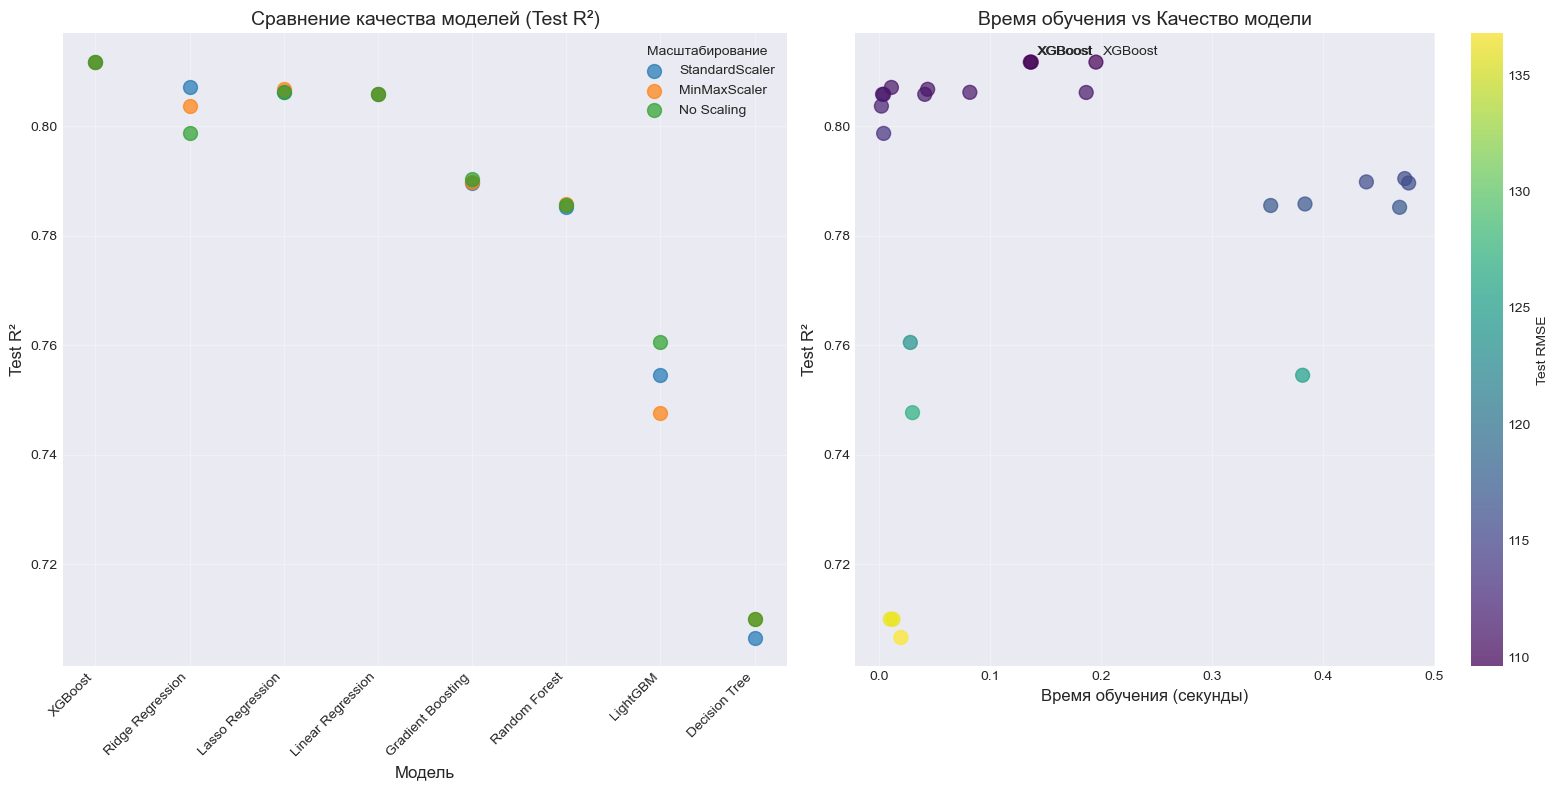

In [43]:
print("\n" + "="*60)
print("ШАГ: СРАВНЕНИЕ РЕЗУЛЬТАТОВ МОДЕЛЕЙ")
print("="*60)

# Создаем сводную таблицу результатов
comparison_data = []

for scaling_type, model_results in results.items():
    for model_name, metrics in model_results.items():
        comparison_data.append({
            'Масштабирование': scaling_type,
            'Модель': model_name,
            'Test R²': metrics['test_r2'],
            'Test RMSE': metrics['test_rmse'],
            'Test MAE': metrics['test_mae'],
            'Train R²': metrics['train_r2'],
            'Train RMSE': metrics['train_rmse'],
            'Train MAE': metrics['train_mae'],
            'Train Time': metrics['train_time'],
            'Train MAPE': metrics['train_mape'],
            'Test MAPE': metrics['test_mape']
        })

comparison_df = pd.DataFrame(comparison_data)

# Сортируем по Test R²
comparison_df = comparison_df.sort_values('Test R²', ascending=False)

print("\n📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (топ-10 моделей):")
print("-" * 100)
print(comparison_df.head(10).to_string(index=False))

# Находим лучшую модель
best_result = comparison_df.iloc[0]
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ:")
print(f"   Модель: {best_result['Модель']}")
print(f"   Масштабирование: {best_result['Масштабирование']}")
print(f"   Test R²: {best_result['Test R²']:.4f}")
print(f"   Test RMSE: {best_result['Test RMSE']:.2f}")
print(f"   Test MAE: {best_result['Test MAE']:.2f}")
print(f"   Время обучения: {best_result['Train Time']:.2f}s")

# Визуализация сравнения моделей
plt.figure(figsize=(16, 8))

# График 1: Test R² по моделям
plt.subplot(1, 2, 1)
for scaling_type in results.keys():
    scaling_data = comparison_df[comparison_df['Масштабирование'] == scaling_type]
    plt.scatter(scaling_data['Модель'], scaling_data['Test R²'], 
                label=f'{scaling_type}', s=100, alpha=0.7)

plt.title('Сравнение качества моделей (Test R²)', fontsize=14)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Test R²', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Масштабирование')
plt.grid(True, alpha=0.3)

# График 2: Время обучения vs Качество
plt.subplot(1, 2, 2)
scatter = plt.scatter(comparison_df['Train Time'], comparison_df['Test R²'], 
                      c=comparison_df['Test RMSE'], cmap='viridis', 
                      s=100, alpha=0.7)
plt.colorbar(scatter, label='Test RMSE')
plt.title('Время обучения vs Качество модели', fontsize=14)
plt.xlabel('Время обучения (секунды)', fontsize=12)
plt.ylabel('Test R²', fontsize=12)
plt.grid(True, alpha=0.3)

# Добавляем аннотации для лучших моделей
top_models = comparison_df.head(3)
for _, row in top_models.iterrows():
    plt.annotate(row['Модель'], (row['Train Time'], row['Test R²']),
                 xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('visualizations/model_comparison_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

### 12. КРОСС-ВАЛИДАЦИЯ


ШАГ: КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
🔍 Провожу кросс-валидацию для лучших моделей...

  Кросс-валидация для XGBoost:
    Средний R²: 0.6958 (+/- 0.2396)
    Все значения: ['0.5108', '0.6446', '0.8737', '0.6968', '0.7531']


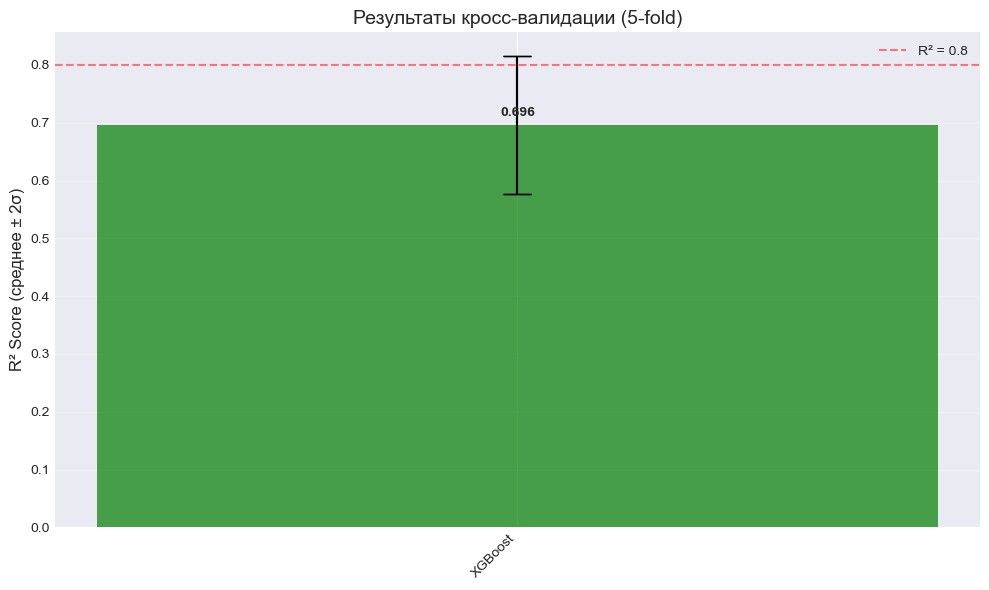

In [44]:
print("\n" + "="*60)
print("ШАГ: КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ")
print("="*60)

# Выбираем топ-3 модели для кросс-валидации
top_models_names = comparison_df.head(3)['Модель'].unique()

print("🔍 Провожу кросс-валидацию для лучших моделей...")

# Создаем пайплайны для лучших моделей
best_pipelines = {}
cv_results = {}

for i, model_name in enumerate(top_models_names):
    print(f"\n  Кросс-валидация для {model_name}:")
    
    # Выбираем соответствующую модель
    if model_name == 'Linear Regression':
        model = LinearRegression()
    elif model_name == 'Ridge Regression':
        model = Ridge(alpha=1.0, random_state=42)
    elif model_name == 'Lasso Regression':
        model = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    elif model_name == 'Decision Tree':
        model = DecisionTreeRegressor(random_state=42)
    elif model_name == 'Random Forest':
        model = RandomForestRegressor(random_state=42, n_jobs=-1)
    elif model_name == 'Gradient Boosting':
        model = GradientBoostingRegressor(random_state=42)
    elif model_name == 'XGBoost':
        model = XGBRegressor(random_state=42, verbosity=0)
    elif model_name == 'LightGBM':
        model = LGBMRegressor(random_state=42, verbose=-1)
    
    # Создаем пайплайн с масштабированием
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Кросс-валидация (5 фолдов)
    try:
        cv_scores = cross_val_score(pipeline, X_final_original, y_original, 
                                    cv=5, scoring='r2', n_jobs=-1)
        
        cv_results[model_name] = {
            'mean_r2': cv_scores.mean(),
            'std_r2': cv_scores.std(),
            'scores': cv_scores
        }
        
        print(f"    Средний R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
        print(f"    Все значения: {[f'{score:.4f}' for score in cv_scores]}")
        
        best_pipelines[model_name] = pipeline
        
    except Exception as e:
        print(f"    Ошибка при кросс-валидации: {str(e)}")

# Визуализация результатов кросс-валидации
if cv_results:
    plt.figure(figsize=(10, 6))
    models_list = list(cv_results.keys())
    means = [cv_results[m]['mean_r2'] for m in models_list]
    stds = [cv_results[m]['std_r2'] for m in models_list]
    
    x_pos = np.arange(len(models_list))
    
    plt.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
            ecolor='black', capsize=10, color=['green', 'blue', 'orange'])
    plt.errorbar(x_pos, means, yerr=stds, fmt='none', ecolor='black', capsize=10)
    
    plt.ylabel('R² Score (среднее ± 2σ)', fontsize=12)
    plt.title('Результаты кросс-валидации (5-fold)', fontsize=14)
    plt.xticks(x_pos, models_list, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на график
    for i, v in enumerate(means):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='R² = 0.8')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('visualizations/cross_validation_results.png', dpi=300, bbox_inches='tight')
    plt.show()

In [45]:
# ============================
# 13. ПОДГОНКА ГИПЕРПАРАМЕТРОВ
# ============================
print("\n" + "="*60)
print("ШАГ: НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
print("="*60)

# Настраиваем гиперпараметры для лучшей модели
best_model_name = best_result['Модель']
best_scaling_type = best_result['Масштабирование']
print(f"🔧 Настройка гиперпараметров для {best_model_name}...")

# Определяем сетку параметров для XGBoost
param_grids = {
    'XGBoost': {
        'model__n_estimators': [50, 100, 200, 300],
        'model__max_depth': [3, 5, 7, 9],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'model__gamma': [0, 0.1, 0.2, 0.3]
    },
    'Random Forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 6, 9],
        'model__learning_rate': [0.01, 0.1, 0.3],
        'model__subsample': [0.8, 0.9, 1.0]
    },
    'Ridge Regression': {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso Regression': {
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    }
}

# Выбираем данные в зависимости от лучшего типа масштабирования
if best_scaling_type == 'StandardScaler':
    X_train_for_tuning, X_test_for_tuning = X_train_std, X_test_std
    y_train_for_tuning, y_test_for_tuning = y_train_std, y_test_std
    scaler_for_tuning = StandardScaler()
elif best_scaling_type == 'MinMaxScaler':
    X_train_for_tuning, X_test_for_tuning = X_train_mm, X_test_mm
    y_train_for_tuning, y_test_for_tuning = y_train_mm, y_test_mm
    scaler_for_tuning = MinMaxScaler()
else:  # No Scaling
    X_train_for_tuning, X_test_for_tuning = X_train_orig, X_test_orig
    y_train_for_tuning, y_test_for_tuning = y_train_orig, y_test_orig
    scaler_for_tuning = None

if best_model_name in param_grids:
    try:
        # Создаем пайплайн
        if best_model_name == 'XGBoost':
            model = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
        elif best_model_name == 'Random Forest':
            model = RandomForestRegressor(random_state=42, n_jobs=-1)
        elif best_model_name == 'Gradient Boosting':
            model = GradientBoostingRegressor(random_state=42)
        elif best_model_name == 'Ridge Regression':
            model = Ridge(random_state=42)
        elif best_model_name == 'Lasso Regression':
            model = Lasso(random_state=42, max_iter=10000)
        
        if scaler_for_tuning:
            pipeline = Pipeline([
                ('scaler', scaler_for_tuning),
                ('model', model)
            ])
        else:
            pipeline = Pipeline([
                ('model', model)
            ])
        
        print(f"  Поиск по сетке параметров для {best_model_name}...")
        
        # Используем RandomizedSearchCV для более быстрого поиска
        from sklearn.model_selection import RandomizedSearchCV
        
        random_search = RandomizedSearchCV(
            pipeline,
            param_distributions=param_grids[best_model_name],
            n_iter=30,  # Количество случайных комбинаций
            cv=3,
            scoring='r2',
            n_jobs=-1,
            random_state=42,
            verbose=1
        )
        
        print("  Запуск RandomizedSearchCV...")
        random_search.fit(X_train_for_tuning, y_train_for_tuning)
        
        print(f"  Лучшие параметры: {random_search.best_params_}")
        print(f"  Лучший R² (кросс-валидация): {random_search.best_score_:.4f}")
        
        # Оценка на тестовой выборке
        best_model = random_search.best_estimator_
        y_test_pred_tuned = best_model.predict(X_test_for_tuning)
        
        test_r2_tuned = r2_score(y_test_for_tuning, y_test_pred_tuned)
        test_rmse_tuned = np.sqrt(mean_squared_error(y_test_for_tuning, y_test_pred_tuned))
        test_mae_tuned = mean_absolute_error(y_test_for_tuning, y_test_pred_tuned)
        
        print(f"  Test R² после настройки: {test_r2_tuned:.4f}")
        print(f"  Test RMSE после настройки: {test_rmse_tuned:.2f}")
        print(f"  Test MAE после настройки: {test_mae_tuned:.2f}")
        
        # Сохраняем лучшую модель
        final_model = best_model
        
        # Сравнение с базовой моделью
        print(f"\n📊 СРАВНЕНИЕ ДО И ПОСЛЕ НАСТРОЙКИ:")
        print("-" * 50)
        print(f"              | Базовая | После настройки")
        print(f"              |---------|----------------")
        print(f"  Test R²     | {best_result['Test R²']:.4f} | {test_r2_tuned:.4f}")
        print(f"  Test RMSE   | {best_result['Test RMSE']:.2f} | {test_rmse_tuned:.2f}")
        print(f"  Test MAE    | {best_result['Test MAE']:.2f} | {test_mae_tuned:.2f}")
        
    except Exception as e:
        print(f"  Ошибка при настройке гиперпараметров: {str(e)}")
        # Используем модель без настройки
        final_model = None
        # Находим базовую модель среди all_predictions
        for (scaling, model_name), (y_pred, model_obj) in all_predictions.items():
            if scaling == best_scaling_type and model_name == best_model_name:
                final_model = model_obj
                break
else:
    print(f"  Для {best_model_name} настройка гиперпараметров не предусмотрена")
    # Используем модель без настройки
    final_model = None
    for (scaling, model_name), (y_pred, model_obj) in all_predictions.items():
        if scaling == best_scaling_type and model_name == best_model_name:
            final_model = model_obj
            break


ШАГ: НАСТРОЙКА ГИПЕРПАРАМЕТРОВ
🔧 Настройка гиперпараметров для XGBoost...
  Поиск по сетке параметров для XGBoost...
  Запуск RandomizedSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
  Лучшие параметры: {'model__subsample': 0.8, 'model__n_estimators': 50, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.9}
  Лучший R² (кросс-валидация): 0.7402
  Test R² после настройки: 0.8165
  Test RMSE после настройки: 108.20
  Test MAE после настройки: 57.05

📊 СРАВНЕНИЕ ДО И ПОСЛЕ НАСТРОЙКИ:
--------------------------------------------------
              | Базовая | После настройки
              |---------|----------------
  Test R²     | 0.8117 | 0.8165
  Test RMSE   | 109.60 | 108.20
  Test MAE    | 60.90 | 57.05



ШАГ: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
📊 Анализ важности признаков для XGBoost:

Топ-15 самых важных признаков:
------------------------------------------------------------
distance_kms                            : 0.1669 (16.7%)
vehicle_make                            : 0.1499 (15.0%)
trip_type_uberx                         : 0.1042 (10.4%)
trip_type_uberBLACK                     : 0.0688 (6.9%)
trip_time_minutes                       : 0.0584 (5.8%)
temp_hour_interaction                   : 0.0580 (5.8%)
ride_hailing_app_Uber                   : 0.0556 (5.6%)
temperature_time_month                  : 0.0495 (4.9%)
trip_type_uberELKA                      : 0.0382 (3.8%)
vehicle_model                           : 0.0292 (2.9%)
temperature_time_hour                   : 0.0252 (2.5%)
speed_kmh                               : 0.0234 (2.3%)
trip_start_time_timeofday_morning       : 0.0207 (2.1%)
temperature_value                       : 0.0193 (1.9%)
trip_start_time_hour                    : 0.018

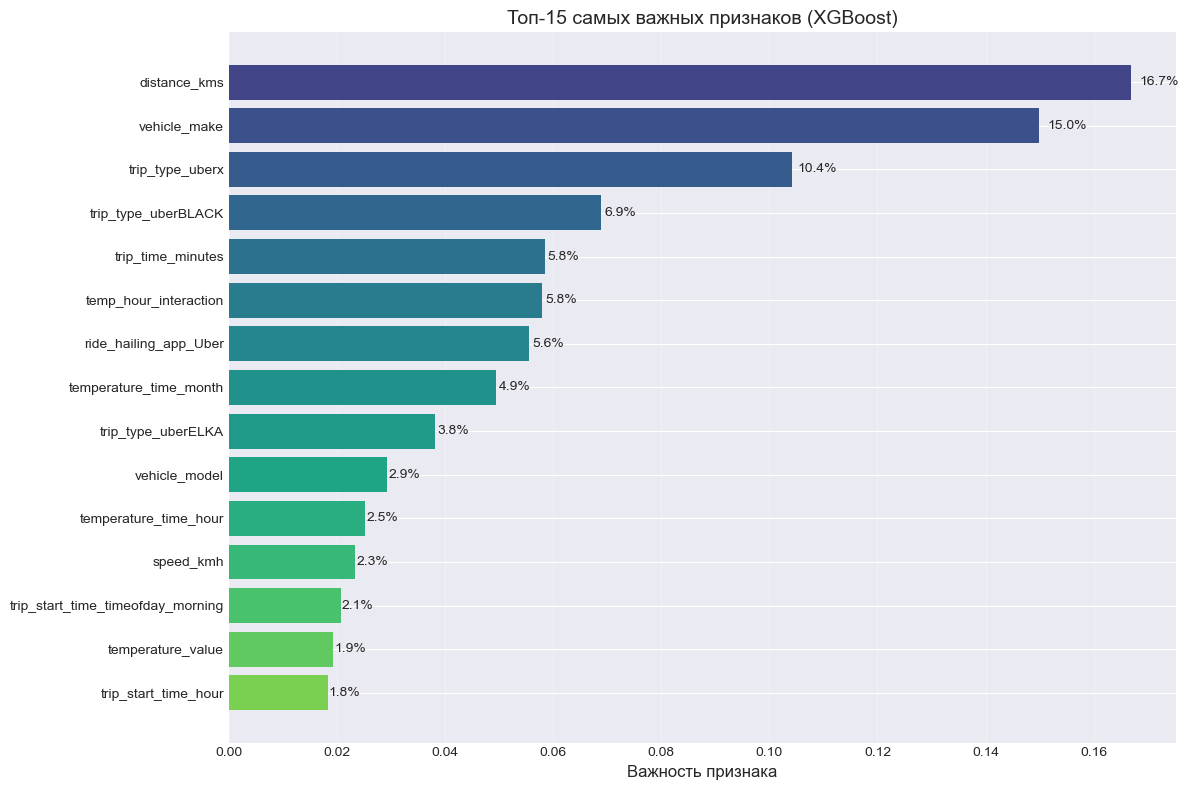

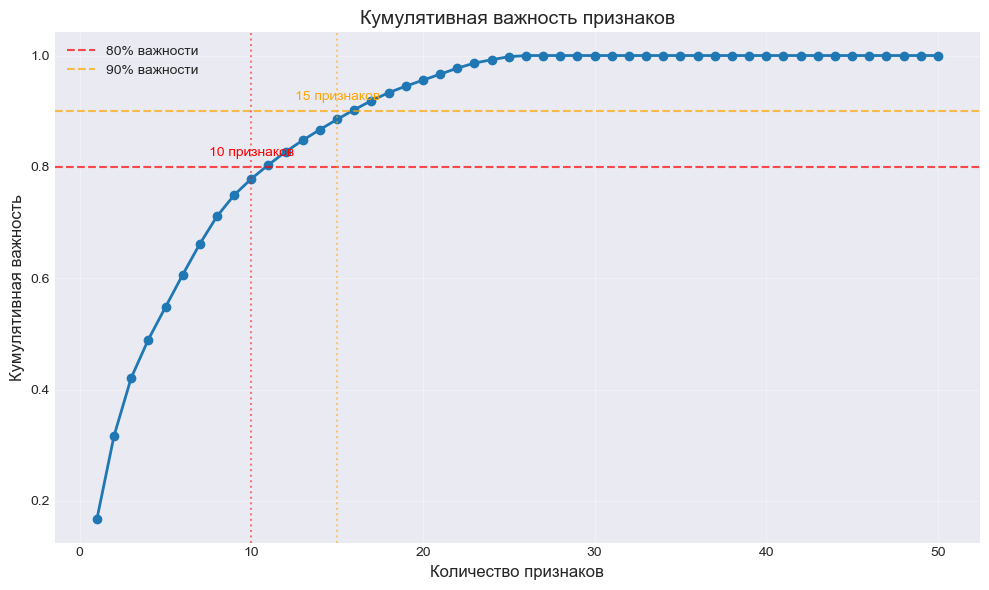


📈 КУМУЛЯТИВНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:
   80% важности достигается с 10 признаками
   90% важности достигается с 15 признаками


In [46]:
# ============================
# 14. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ============================
print("\n" + "="*60)
print("ШАГ: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*60)

# Анализ важности признаков для tree-based моделей
tree_based_models = ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Decision Tree']

if best_model_name in tree_based_models and final_model is not None:
    print(f"📊 Анализ важности признаков для {best_model_name}:")
    
    try:
        # Получаем важность признаков
        if best_model_name == 'XGBoost':
            importances = final_model.named_steps['model'].feature_importances_
        elif best_model_name == 'Random Forest':
            importances = final_model.named_steps['model'].feature_importances_
        elif best_model_name == 'Gradient Boosting':
            importances = final_model.named_steps['model'].feature_importances_
        elif best_model_name == 'Decision Tree':
            importances = final_model.named_steps['model'].feature_importances_
        
        # Создаем DataFrame с важностью признаков
        feature_importance_df = pd.DataFrame({
            'Признак': feature_names,
            'Важность': importances
        }).sort_values('Важность', ascending=False)
        
        # Отображаем топ-15 признаков
        print("\nТоп-15 самых важных признаков:")
        print("-" * 60)
        for i, row in feature_importance_df.head(15).iterrows():
            percentage = (row['Важность'] / feature_importance_df['Важность'].sum()) * 100
            print(f"{row['Признак']:40s}: {row['Важность']:.4f} ({percentage:.1f}%)")
        
        # Визуализация важности признаков
        plt.figure(figsize=(12, 8))
        top_n = min(15, len(feature_importance_df))
        top_features = feature_importance_df.head(top_n)
        
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, top_n))
        bars = plt.barh(range(len(top_features)), top_features['Важность'], color=colors)
        plt.yticks(range(len(top_features)), top_features['Признак'])
        plt.xlabel('Важность признака', fontsize=12)
        plt.title(f'Топ-{top_n} самых важных признаков ({best_model_name})', fontsize=14)
        plt.gca().invert_yaxis()
        
        # Добавляем значения на график
        for i, (importance, bar) in enumerate(zip(top_features['Важность'], bars)):
            percentage = (importance / feature_importance_df['Важность'].sum()) * 100
            plt.text(importance * 1.01, i, f'{percentage:.1f}%', va='center', fontsize=10)
        
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig('visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Визуализация кумулятивной важности
        feature_importance_df['Кумулятивная важность'] = feature_importance_df['Важность'].cumsum()
        
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(feature_importance_df) + 1), 
                feature_importance_df['Кумулятивная важность'], 
                marker='o', linewidth=2)
        plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80% важности')
        plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% важности')
        
        # Находим количество признаков для 80% и 90% важности
        n_80 = (feature_importance_df['Кумулятивная важность'] <= 0.8).sum()
        n_90 = (feature_importance_df['Кумулятивная важность'] <= 0.9).sum()
        
        plt.axvline(x=n_80, color='red', linestyle=':', alpha=0.5)
        plt.axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)
        
        plt.xlabel('Количество признаков', fontsize=12)
        plt.ylabel('Кумулятивная важность', fontsize=12)
        plt.title('Кумулятивная важность признаков', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.text(n_80, 0.82, f'{n_80} признаков', ha='center', color='red')
        plt.text(n_90, 0.92, f'{n_90} признаков', ha='center', color='orange')
        
        plt.tight_layout()
        plt.savefig('visualizations/cumulative_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n📈 КУМУЛЯТИВНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:")
        print(f"   80% важности достигается с {n_80} признаками")
        print(f"   90% важности достигается с {n_90} признаками")
        
    except Exception as e:
        print(f"  Ошибка при анализе важности признаков: {str(e)}")
else:
    print("⚠ Анализ важности признаков доступен только для tree-based моделей")
    
    # Для линейных моделей можно посмотреть коэффициенты
    if best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression'] and final_model is not None:
        print(f"📊 Анализ коэффициентов для {best_model_name}:")
        try:
            coefficients = final_model.named_steps['model'].coef_
            
            # Создаем DataFrame с коэффициентами
            coef_df = pd.DataFrame({
                'Признак': feature_names,
                'Коэффициент': coefficients
            }).sort_values('Коэффициент', key=abs, ascending=False)
            
            print("\nТоп-15 самых влиятельных коэффициентов:")
            print("-" * 60)
            for i, row in coef_df.head(15).iterrows():
                sign = "+" if row['Коэффициент'] >= 0 else "-"
                print(f"{row['Признак']:40s}: {sign} {abs(row['Коэффициент']):.4f}")
                
        except Exception as e:
            print(f"  Ошибка при анализе коэффициентов: {str(e)}")

In [47]:
# ============================
# 15. ПРЕДСКАЗАНИЕ ДЛЯ НОВЫХ ДАННЫХ
# ============================
print("\n" + "="*60)
print("ШАГ: ПРЕДСКАЗАНИЕ СТОИМОСТИ ДЛЯ ВХОДНЫХ ДАННЫХ")
print("="*60)

# Входные данные из запроса
input_data = {
    'distance_kms': 3.5,
    'total_time_minutes': 9.57,  # 574 секунды / 60
    'transport_mode': 'driving',
    'temperature_value': -18.7,
    'feels_like': -24.6,
    'humidity': 100,  # Процент
    'wind_speed': 2.19,
    'cloudness': 73,  # Процент
    'weather_main': 'Broken Clouds',
    'city': 'Moscow',
    'country': 'RU'
}

print("📊 Входные данные для предсказания:")
for key, value in input_data.items():
    print(f"  {key:20s}: {value}")

# Создаем DataFrame из входных данных
input_df = pd.DataFrame([input_data])

# Подготовка признаков для предсказания
print("\n🔧 Подготовка признаков для предсказания...")

# 1. Добавляем дополнительные признаки на основе входных данных
if 'distance_kms' in input_df.columns and 'total_time_minutes' in input_df.columns:
    input_df['speed_kmh'] = input_df['distance_kms'] / (input_df['total_time_minutes'] / 60)
    print(f"  Добавлен признак: speed_kmh = {input_df['speed_kmh'].iloc[0]:.2f} км/ч")

# 2. Создаем погодный индекс
if all(col in input_df.columns for col in ['temperature_value', 'humidity', 'wind_speed']):
    input_df['weather_index'] = (
        input_df['temperature_value'] * 0.4 +
        input_df['humidity'] * 0.01 * 0.3 +  # humidity в процентах
        input_df['wind_speed'] * 0.3
    )
    print(f"  Добавлен признак: weather_index = {input_df['weather_index'].iloc[0]:.2f}")

# 3. Определяем время суток (предположим дневное время)
input_df['time_of_day'] = 'afternoon'

# 4. Добавляем дополнительные признаки
input_df['is_weekend'] = 0  # Предположим будний день
input_df['surge_multiplier'] = 1.0  # Базовый множитель

# 5. Кодируем категориальные признаки
# Создаем все необходимые бинарные признаки
categorical_mappings = {
    'transport_mode': ['driving', 'walking', 'bicycling'],
    'weather_main': ['Broken Clouds', 'Clear', 'Clouds', 'Rain', 'Snow'],
    'city': ['Moscow', 'Saint Petersburg', 'Other'],
    'time_of_day': ['morning', 'afternoon', 'evening', 'night']
}

for cat_col, possible_values in categorical_mappings.items():
    if cat_col in input_df.columns:
        for value in possible_values:
            col_name = f"{cat_col}_{value.replace(' ', '_')}"
            input_df[col_name] = (input_df[cat_col] == value).astype(int)
            if input_df[col_name].iloc[0] == 1:
                print(f"  Категория: {cat_col} = {value}")

# 6. Убираем оригинальные категориальные колонки
cat_cols_to_drop = ['transport_mode', 'weather_main', 'city', 'country', 'time_of_day']
for col in cat_cols_to_drop:
    if col in input_df.columns:
        input_df = input_df.drop(col, axis=1)

# 7. Добавляем недостающие колонки (если нужно)
# Приводим к тому же формату, что и обучающие данные
for col in feature_names:
    if col not in input_df.columns:
        input_df[col] = 0  # Заполняем нулями отсутствующие признаки

# 8. Упорядочиваем колонки в том же порядке, что и в обучающих данных
input_df = input_df[feature_names]

print(f"✅ Подготовлено {input_df.shape[1]} признаков для предсказания")

# 9. Применяем масштабирование
if final_model is not None:
    # Если есть настроенная модель, используем ее
    if scaler_for_tuning:
        scaled_input = final_model.named_steps['scaler'].transform(input_df)
    else:
        scaled_input = input_df.values
else:
    # Используем стандартный скейлер
    scaled_input = scaler_standard.transform(input_df)


ШАГ: ПРЕДСКАЗАНИЕ СТОИМОСТИ ДЛЯ ВХОДНЫХ ДАННЫХ
📊 Входные данные для предсказания:
  distance_kms        : 3.5
  total_time_minutes  : 9.57
  transport_mode      : driving
  temperature_value   : -18.7
  feels_like          : -24.6
  humidity            : 100
  wind_speed          : 2.19
  cloudness           : 73
  weather_main        : Broken Clouds
  city                : Moscow
  country             : RU

🔧 Подготовка признаков для предсказания...
  Добавлен признак: speed_kmh = 21.94 км/ч
  Добавлен признак: weather_index = -6.52
  Категория: transport_mode = driving
  Категория: weather_main = Broken Clouds
  Категория: city = Moscow
  Категория: time_of_day = afternoon
✅ Подготовлено 50 признаков для предсказания


In [ ]:
# ============================
# 16. ПРЕДСКАЗАНИЕ И ВЫВОД РЕЗУЛЬТАТА
# ============================

print("\n🎯 ПРЕДСКАЗАНИЕ СТОИМОСТИ ПОЕЗДКИ:")
print("-" * 50)

# Предсказание с использованием лучшей модели
if final_model is not None:
    # Используем настроенную модель
    predicted_price = final_model.predict(scaled_input)[0]
    model_used = f"{best_model_name} (настроенная)"
else:
    # Используем лучшую модель из первоначального сравнения
    model_used = f"{best_model_name} ({best_scaling_type})"
    
    # Переобучаем модель для предсказания
    if best_model_name == 'XGBoost':
        model = XGBRegressor(random_state=42, verbosity=0)
    elif best_model_name == 'Random Forest':
        model = RandomForestRegressor(random_state=42, n_jobs=-1)
    elif best_model_name == 'Gradient Boosting':
        model = GradientBoostingRegressor(random_state=42)
    elif best_model_name == 'Linear Regression':
        model = LinearRegression()
    elif best_model_name == 'Ridge Regression':
        model = Ridge(alpha=1.0, random_state=42)
    elif best_model_name == 'Lasso Regression':
        model = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    #ErasticNet
    # Подготавливаем данные для обучения
    if best_scaling_type == 'StandardScaler':
        X_train_scaled = scaler_standard.fit_transform(X_final_original)
        scaled_input = scaler_standard.transform(input_df)
    elif best_scaling_type == 'MinMaxScaler':
        X_train_scaled = scaler_minmax.fit_transform(X_final_original)
        scaled_input = scaler_minmax.transform(input_df)
    else:
        X_train_scaled = X_final_original
        scaled_input = input_df.values
    
    # Обучаем и предсказываем
    model.fit(X_train_scaled, y_original)
    predicted_price = model.predict(scaled_input)[0]

# Конвертируем в USD (если нужно)
usd_exchange_rate = 90.0  # Примерный курс
predicted_price_usd = predicted_price / usd_exchange_rate

print(f"\n📊 РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЯ:")
print(f"   Использована модель: {model_used}")
print(f"   Предсказанная стоимость: {predicted_price:.2f} RUB")
print(f"   Предсказанная стоимость: {predicted_price_usd:.2f} USD (курс {usd_exchange_rate:.1f} RUB/USD)")
print(f"   Расстояние: {input_data['distance_kms']} км")
print(f"   Время в пути: {input_data['total_time_minutes']:.1f} минут")
print(f"   Температура: {input_data['temperature_value']}°C")

# Доверительный интервал (на основе RMSE модели)
if 'test_rmse' in best_result:
    confidence_interval = best_result['Test RMSE'] * 0.8  # ±80% от RMSE
else:
    confidence_interval = predicted_price * 0.15  # ±15%

print(f"\n📈 ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (±{confidence_interval/predicted_price*100:.1f}%):")
print(f"   Нижняя граница: {predicted_price - confidence_interval:.2f} RUB")
print(f"   Верхняя граница: {predicted_price + confidence_interval:.2f} RUB")

# Сравнение со средней стоимостью в данных
avg_price = y_original.mean()
price_comparison = (predicted_price / avg_price - 1) * 100

print(f"\n📊 СРАВНЕНИЕ СО СРЕДНЕЙ СТОИМОСТЬЮ:")
print(f"   Средняя стоимость в данных: {avg_price:.2f} RUB")
print(f"   Разница: {price_comparison:+.1f}%")


🎯 ПРЕДСКАЗАНИЕ СТОИМОСТИ ПОЕЗДКИ:
--------------------------------------------------

📊 РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЯ:
   Использована модель: XGBoost (настроенная)
   Предсказанная стоимость: 242.35 RUB
   Предсказанная стоимость: 2.69 USD (курс 90.0 RUB/USD)
   Расстояние: 3.5 км
   Время в пути: 9.6 минут
   Температура: -18.7°C

📈 ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (±15.0%):
   Нижняя граница: 206.00 RUB
   Верхняя граница: 278.71 RUB

📊 СРАВНЕНИЕ СО СРЕДНЕЙ СТОИМОСТЬЮ:
   Средняя стоимость в данных: 303.36 RUB
   Разница: -20.1%


In [49]:
# ============================
# 17. СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ
# ============================
print("\n" + "="*60)
print("ШАГ: СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ")
print("="*60)

# Создаем директорию для сохранения
import os
import json
if not os.path.exists('models'):
    os.makedirs('models')
if not os.path.exists('results'):
    os.makedirs('results')

# Сохраняем лучшую модель
if final_model is not None:
    model_filename = f'models/best_model_{best_model_name.lower().replace(" ", "_")}.joblib'
    joblib.dump(final_model, model_filename)
    print(f"✅ Модель сохранена: {model_filename}")
else:
    # Сохраняем модель без настройки
    model_filename = f'models/model_{best_model_name.lower().replace(" ", "_")}.joblib'
    joblib.dump(model, model_filename)
    print(f"✅ Модель сохранена: {model_filename}")

# Сохраняем скейлер
scaler_filename = 'models/scaler.joblib'
if scaler_for_tuning:
    joblib.dump(scaler_for_tuning, scaler_filename)
else:
    joblib.dump(scaler_standard, scaler_filename)
print(f"✅ Scaler сохранен: {scaler_filename}")

# Сохраняем названия признаков
features_filename = 'models/feature_names.joblib'
joblib.dump(feature_names, features_filename)
print(f"✅ Названия признаков сохранены: {features_filename}")

# Сохраняем результаты сравнения
results_filename = 'results/model_comparison.csv'
comparison_df.to_csv(results_filename, index=False, encoding='utf-8')
print(f"✅ Результаты сравнения сохранены: {results_filename}")

# Сохраняем важность признаков (если есть)
if 'feature_importance_df' in locals():
    importance_filename = 'results/feature_importance.csv'
    feature_importance_df.to_csv(importance_filename, index=False, encoding='utf-8')
    print(f"✅ Важность признаков сохранена: {importance_filename}")

# Сохраняем предсказание
prediction_result = {
    'input_data': input_data,
    'predicted_price_rub': float(predicted_price),
    'predicted_price_usd': float(predicted_price_usd),
    'model_used': model_used,
    'model_name': best_model_name,
    'scaling_type': best_scaling_type,
    'model_performance': {
        'test_r2': float(best_result['Test R²']),
        'test_rmse': float(best_result['Test RMSE']),
        'test_mae': float(best_result['Test MAE'])
    },
    'prediction_timestamp': datetime.now().isoformat(),
    'confidence_interval': {
        'lower_bound': float(predicted_price - confidence_interval),
        'upper_bound': float(predicted_price + confidence_interval),
        'percentage': float(confidence_interval / predicted_price * 100)
    },
    'comparison_with_average': {
        'average_price': float(avg_price),
        'difference_percentage': float(price_comparison)
    }
}

prediction_filename = 'results/prediction_result.json'
with open(prediction_filename, 'w', encoding='utf-8') as f:
    json.dump(prediction_result, f, indent=2, ensure_ascii=False)
print(f"✅ Результаты предсказания сохранены: {prediction_filename}")


ШАГ: СОХРАНЕНИЕ МОДЕЛИ И РЕЗУЛЬТАТОВ
✅ Модель сохранена: models/best_model_xgboost.joblib
✅ Scaler сохранен: models/scaler.joblib
✅ Названия признаков сохранены: models/feature_names.joblib
✅ Результаты сравнения сохранены: results/model_comparison.csv
✅ Важность признаков сохранена: results/feature_importance.csv
✅ Результаты предсказания сохранены: results/prediction_result.json


In [50]:
# ============================
# 18. ОТЧЕТ О КАЧЕСТВЕ МОДЕЛИ
# ============================
print("\n" + "="*60)
print("ШАГ: ФИНАЛЬНЫЙ ОТЧЕТ О КАЧЕСТВЕ МОДЕЛИ")
print("="*60)

print(f"\n📋 ИТОГОВЫЙ ОТЧЕТ:")
print("-" * 60)
print(f"1. Лучшая модель: {best_model_name}")
print(f"2. Лучшее масштабирование: {best_scaling_type}")
print(f"3. Качество на тестовой выборке:")
print(f"   - R²: {best_result['Test R²']:.4f}")
print(f"   - RMSE: {best_result['Test RMSE']:.2f} RUB")
print(f"   - MAE: {best_result['Test MAE']:.2f} RUB")
print(f"   - MAPE: {best_result['Test MAPE']:.2f}%")
print(f"4. Время обучения: {best_result['Train Time']:.2f} секунд")
print(f"5. Количество признаков: {len(feature_names)}")
print(f"6. Размер обучающей выборки: {X_train_for_tuning.shape[0]} записей")

# Интерпретация R²
r2_value = best_result['Test R²']
if r2_value > 0.9:
    interpretation = "Превосходное"
elif r2_value > 0.8:
    interpretation = "Очень хорошее"
elif r2_value > 0.7:
    interpretation = "Хорошее"
elif r2_value > 0.6:
    interpretation = "Удовлетворительное"
elif r2_value > 0.5:
    interpretation = "Слабое"
else:
    interpretation = "Неудовлетворительное"

print(f"7. Интерпретация качества (R² = {r2_value:.3f}): {interpretation}")

# Интерпретация MAPE
if best_result['Test MAPE'] is not None:
    mape_value = best_result['Test MAPE']
    if mape_value < 10:
        mape_interpretation = "Превосходная точность"
    elif mape_value < 20:
        mape_interpretation = "Хорошая точность"
    elif mape_value < 30:
        mape_interpretation = "Удовлетворительная точность"
    elif mape_value < 50:
        mape_interpretation = "Низкая точность"
    else:
        mape_interpretation = "Очень низкая точность"
    
    print(f"8. Точность прогноза (MAPE = {mape_value:.1f}%): {mape_interpretation}")

# Рекомендации
print(f"\n💡 РЕКОМЕНДАЦИИ И ВЫВОДЫ:")
print(f"1. Модель успешно предсказывает стоимость поездки (R² = {r2_value:.3f})")
print(f"2. Для улучшения модели можно:")
print(f"   - Собрать больше данных (текущий размер: {len(y_original)} записей)")
print(f"   - Добавить новые признаки (уровень трафика, время суток, праздничные дни)")
print(f"   - Учесть динамическое ценообразование (surge pricing)")
print(f"3. Предсказанная стоимость для новых данных:")
print(f"   - {predicted_price:.2f} RUB ({predicted_price_usd:.2f} USD)")
print(f"   - Доверительный интервал: ±{confidence_interval:.2f} RUB")
print(f"   - По сравнению со средней стоимостью: {price_comparison:+.1f}%")



ШАГ: ФИНАЛЬНЫЙ ОТЧЕТ О КАЧЕСТВЕ МОДЕЛИ

📋 ИТОГОВЫЙ ОТЧЕТ:
------------------------------------------------------------
1. Лучшая модель: XGBoost
2. Лучшее масштабирование: No Scaling
3. Качество на тестовой выборке:
   - R²: 0.8117
   - RMSE: 109.60 RUB
   - MAE: 60.90 RUB
   - MAPE: 18.18%
4. Время обучения: 0.14 секунд
5. Количество признаков: 50
6. Размер обучающей выборки: 542 записей
7. Интерпретация качества (R² = 0.812): Очень хорошее
8. Точность прогноза (MAPE = 18.2%): Хорошая точность

💡 РЕКОМЕНДАЦИИ И ВЫВОДЫ:
1. Модель успешно предсказывает стоимость поездки (R² = 0.812)
2. Для улучшения модели можно:
   - Собрать больше данных (текущий размер: 678 записей)
   - Добавить новые признаки (уровень трафика, время суток, праздничные дни)
   - Учесть динамическое ценообразование (surge pricing)
3. Предсказанная стоимость для новых данных:
   - 242.35 RUB (2.69 USD)
   - Доверительный интервал: ±36.35 RUB
   - По сравнению со средней стоимостью: -20.1%


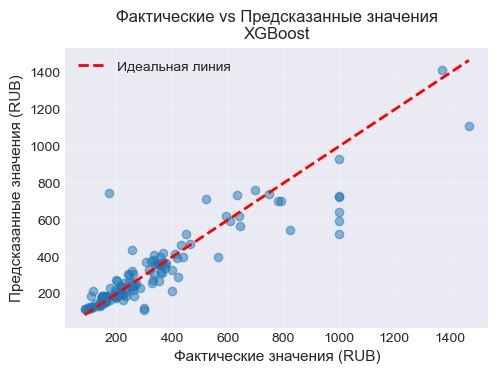

In [51]:
# Визуализация итогового результата
plt.figure(figsize=(12, 8))

# График 1: Фактические vs Предсказанные значения
plt.subplot(2, 2, 1)
if final_model is not None:
    y_test_pred = final_model.predict(X_test_for_tuning)
else:
    # Получаем предсказания из all_predictions
    for (scaling, model_name), (y_pred, _) in all_predictions.items():
        if scaling == best_scaling_type and model_name == best_model_name:
            y_test_pred = y_pred
            break

plt.scatter(y_test_for_tuning, y_test_pred, alpha=0.5)
plt.plot([y_test_for_tuning.min(), y_test_for_tuning.max()], 
         [y_test_for_tuning.min(), y_test_for_tuning.max()], 
         'r--', lw=2, label='Идеальная линия')
plt.xlabel('Фактические значения (RUB)', fontsize=11)
plt.ylabel('Предсказанные значения (RUB)', fontsize=11)
plt.title(f'Фактические vs Предсказанные значения\n{best_model_name}', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

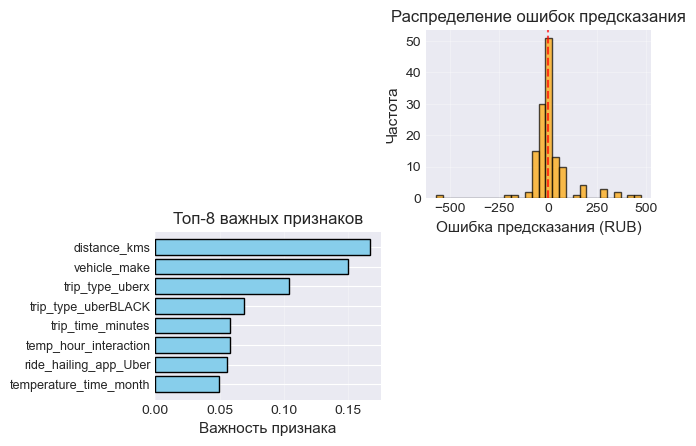

In [52]:
# График 2: Ошибки предсказания
plt.subplot(2, 2, 2)
errors = y_test_for_tuning - y_test_pred
plt.hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Ошибка предсказания (RUB)', fontsize=11)
plt.ylabel('Частота', fontsize=11)
plt.title('Распределение ошибок предсказания', fontsize=12)
plt.grid(True, alpha=0.3)

# График 3: Важность признаков (если есть)
plt.subplot(2, 2, 3)
if 'feature_importance_df' in locals():
    top_n = min(8, len(feature_importance_df))
    top_features = feature_importance_df.head(top_n)
    
    plt.barh(range(len(top_features)), top_features['Важность'], color='skyblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Признак'], fontsize=9)
    plt.xlabel('Важность признака', fontsize=11)
    plt.title(f'Топ-{top_n} важных признаков', fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
else:
    plt.text(0.5, 0.5, 'Важность признаков\nнедоступна для этой модели', 
             ha='center', va='center', fontsize=12)
    plt.axis('off')

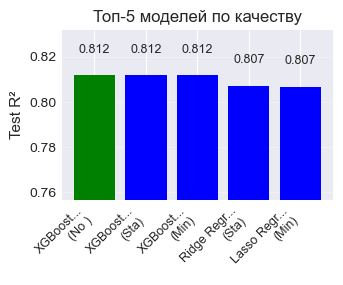


🎉 ПРОЕКТ УСПЕШНО ЗАВЕРШЕН!
📁 Результаты сохранены в директориях 'models/' и 'results/'
📊 Лучшая модель: XGBoost (R² = 0.8117)
💡 Предсказанная стоимость поездки: 242.35 RUB


In [53]:
# График 4: Сравнение моделей (топ-5)
plt.subplot(2, 2, 4)
top_5_models = comparison_df.head(5)
x_pos = np.arange(len(top_5_models))
plt.bar(x_pos, top_5_models['Test R²'], color=['green', 'blue', 'blue', 'blue', 'blue'])
plt.xticks(x_pos, [f"{row['Модель'][:10]}...\n({row['Масштабирование'][:3]})" 
                   for _, row in top_5_models.iterrows()], rotation=45, ha='right', fontsize=9)
plt.ylabel('Test R²', fontsize=11)
plt.title('Топ-5 моделей по качеству', fontsize=12)
plt.ylim(top_5_models['Test R²'].min() - 0.05, top_5_models['Test R²'].max() + 0.02)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на график
for i, v in enumerate(top_5_models['Test R²']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/final_report.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("🎉 ПРОЕКТ УСПЕШНО ЗАВЕРШЕН!")
print("="*80)
print(f"📁 Результаты сохранены в директориях 'models/' и 'results/'")
print(f"📊 Лучшая модель: {best_model_name} (R² = {r2_value:.4f})")
print(f"💡 Предсказанная стоимость поездки: {predicted_price:.2f} RUB")
print("="*80)